# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

The Brain Tumor MRI Image Classification project is a deep learning-based image classification system designed to classify brain MRI images into different tumor categories. The project uses Python and TensorFlow/Keras for image preprocessing, model development, training, and evaluation.

The project follows a complete machine-learning workflow, starting with understanding the MRI dataset and its different categories. The images are preprocessed by resizing them to a consistent size and normalizing pixel values. Data augmentation techniques such as rotation, flipping, zooming, brightness adjustment, and shifting can be used to improve the model's ability to generalize to new MRI images.

Three deep learning models were developed for comparison: Custom CNN, MobileNetV2, and EfficientNetB0. The Custom CNN uses convolutional layers, pooling, batch normalization, and dropout to learn important image features. MobileNetV2 and EfficientNetB0 use transfer learning with pretrained ImageNet models, allowing the system to make use of previously learned image features.

The models are evaluated using Accuracy, Precision, Recall, and F1-Score. Confusion matrices and training-history graphs can also be used to understand model performance. Hyperparameter tuning was performed to improve model performance by testing different configurations such as learning rate, dropout, and dense-layer units.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Brain tumor diagnosis from MRI images can be difficult and time-consuming when performed manually. The problem is to develop a deep learning-based image classification system that can automatically classify brain MRI images into multiple tumor categories. The system will use Custom CNN and transfer-learning models such as MobileNetV2 and EfficientNetB0, evaluate their performance, and provide predictions for new MRI images.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# IMPORT LIBRARIES
# ============================================================

# -----------------------------
# 1. Basic Libraries
# -----------------------------
import os
import warnings
import json

# -----------------------------
# 2. Numerical & Data Handling
# -----------------------------
import numpy as np
import pandas as pd

# -----------------------------
# 3. Visualization
# -----------------------------
import matplotlib.pyplot as plt

# -----------------------------
# 4. Image Processing
# -----------------------------
from PIL import Image

# -----------------------------
# 5. TensorFlow / Keras
# -----------------------------
import tensorflow as tf
from tensorflow import keras

# -----------------------------
# 6. Keras Layers
# -----------------------------
from tensorflow.keras import layers

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

# -----------------------------
# 7. Image Augmentation
# -----------------------------
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.utils import image_dataset_from_directory

# -----------------------------
# 8. Transfer Learning Models
# -----------------------------
from tensorflow.keras.applications import (
    ResNet50,
    MobileNetV2,
    InceptionV3,
    EfficientNetB0
)

# -----------------------------
# 9. Training Callbacks
# -----------------------------
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# -----------------------------
# 10. Warnings
# -----------------------------
warnings.filterwarnings("ignore")

# ============================================================
# CHECK
# ============================================================

print("=" * 60)
print("BRAIN TUMOR MRI IMAGE CLASSIFICATION")
print("=" * 60)

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

print("=" * 60)
print("✅ ALL REQUIRED BASIC LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)

BRAIN TUMOR MRI IMAGE CLASSIFICATION
TensorFlow Version: 2.22.0-rc0
NumPy Version: 2.4.6
Pandas Version: 2.3.3
✅ ALL REQUIRED BASIC LIBRARIES IMPORTED SUCCESSFULLY


### Dataset Loading

In [5]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET LOADING
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. Main Dataset Path
# ------------------------------------------------------------

base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

# ------------------------------------------------------------
# 2. Train / Validation / Test Paths
# ------------------------------------------------------------

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

valid_path = os.path.join(
    base_path,
    "valid-20260930T172018Z-1-001",
    "valid"
)

test_path = os.path.join(
    base_path,
    "test-20260930T171957Z-1-001",
    "test"
)

# ------------------------------------------------------------
# 3. Check Folders
# ------------------------------------------------------------

print("=" * 60)
print("BRAIN TUMOR MRI DATASET")
print("=" * 60)

print("Train folder      :", os.path.exists(train_path))
print("Validation folder :", os.path.exists(valid_path))
print("Test folder       :", os.path.exists(test_path))

# ------------------------------------------------------------
# 4. Find CSV Automatically
# ------------------------------------------------------------

def find_csv(folder):
    csv_files = []

    for file in os.listdir(folder):
        if file.lower().endswith(".csv"):
            csv_files.append(file)

    if len(csv_files) == 0:
        return None

    return os.path.join(folder, csv_files[0])


train_csv = find_csv(train_path)
valid_csv = find_csv(valid_path)
test_csv = find_csv(test_path)

print("\nCSV FILES")
print("-" * 60)

print("Train CSV      :", train_csv)
print("Validation CSV :", valid_csv)
print("Test CSV       :", test_csv)

# ------------------------------------------------------------
# 5. Load CSV Files
# ------------------------------------------------------------

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)
test_df = pd.read_csv(test_csv)

# ------------------------------------------------------------
# 6. Dataset Information
# ------------------------------------------------------------

print("\nDATASET INFORMATION")
print("-" * 60)

print("Training samples   :", len(train_df))
print("Validation samples :", len(valid_df))
print("Testing samples    :", len(test_df))

print("\nTrain shape      :", train_df.shape)
print("Validation shape :", valid_df.shape)
print("Test shape       :", test_df.shape)

# ------------------------------------------------------------
# 7. Display Columns
# ------------------------------------------------------------

print("\nTRAIN COLUMNS")
print("-" * 60)

for column in train_df.columns:
    print(column)

# ------------------------------------------------------------
# 8. Display First 5 Rows
# ------------------------------------------------------------

print("\nFIRST 5 TRAIN RECORDS")
print("-" * 60)

display(train_df.head())

print("\n" + "=" * 60)
print("✅ DATASET LOADED SUCCESSFULLY")
print("=" * 60)

BRAIN TUMOR MRI DATASET
Train folder      : True
Validation folder : True
Test folder       : True

CSV FILES
------------------------------------------------------------
Train CSV      : C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\train-20260930T101539Z-1-001\train\_classes.csv
Validation CSV : C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\valid-20260930T172018Z-1-001\valid\_classes.csv
Test CSV       : C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\test-20260930T171957Z-1-001\test\_classes.csv

DATASET INFORMATION
------------------------------------------------------------
Training samples   : 1695
Validation samples : 502
Testing samples    : 246

Train shape      : (1695, 5)
Validation shape : (502, 5)
Test shape       : (246, 5)

TRAIN COLUMNS
------------------------------------------------------------
filename
 Glioma
 Meningioma
 No Tumor
 Pituitary

FIRST 5 TRAIN RECORDS
------------------------------------------------------------


,filename,Glioma,Meningioma,No Tumor,Pituitary
0,Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...,0,0,0,1
1,Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...,0,0,1,0
2,Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...,1,0,0,0
3,Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...,1,0,0,0
4,Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...,0,1,0,0



✅ DATASET LOADED SUCCESSFULLY


### Dataset First View

In [6]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET FIRST VIEW
# ============================================================

print("=" * 70)
print("BRAIN TUMOR MRI DATASET - FIRST VIEW")
print("=" * 70)

# ------------------------------------------------------------
# 1. Dataset shapes
# ------------------------------------------------------------
print("\n1. DATASET SHAPE")
print("-" * 70)

print("Training data   :", train_df.shape)
print("Validation data :", valid_df.shape)
print("Testing data    :", test_df.shape)


# ------------------------------------------------------------
# 2. Column names
# ------------------------------------------------------------
print("\n2. COLUMN NAMES")
print("-" * 70)

print("Training columns:")
for col in train_df.columns:
    print(" -", col)


# ------------------------------------------------------------
# 3. First 5 rows
# ------------------------------------------------------------
print("\n3. FIRST 5 TRAINING RECORDS")
print("-" * 70)

print(train_df.head())


# ------------------------------------------------------------
# 4. Last 5 rows
# ------------------------------------------------------------
print("\n4. LAST 5 TRAINING RECORDS")
print("-" * 70)

print(train_df.tail())


# ------------------------------------------------------------
# 5. Data types
# ------------------------------------------------------------
print("\n5. DATA TYPES")
print("-" * 70)

print(train_df.dtypes)


# ------------------------------------------------------------
# 6. Missing values
# ------------------------------------------------------------
print("\n6. MISSING VALUES")
print("-" * 70)

print(train_df.isnull().sum())


# ------------------------------------------------------------
# 7. Number of unique values
# ------------------------------------------------------------
print("\n7. UNIQUE VALUES IN EACH COLUMN")
print("-" * 70)

print(train_df.nunique())


# ------------------------------------------------------------
# 8. Basic statistical information
# ------------------------------------------------------------
print("\n8. BASIC STATISTICS")
print("-" * 70)

print(train_df.describe(include="all"))


print("\n" + "=" * 70)
print("✅ DATASET FIRST VIEW COMPLETED")
print("=" * 70)# Dataset First Look

BRAIN TUMOR MRI DATASET - FIRST VIEW

1. DATASET SHAPE
----------------------------------------------------------------------
Training data   : (1695, 5)
Validation data : (502, 5)
Testing data    : (246, 5)

2. COLUMN NAMES
----------------------------------------------------------------------
Training columns:
 - filename
 -  Glioma
 -  Meningioma
 -  No Tumor
 -  Pituitary

3. FIRST 5 TRAINING RECORDS
----------------------------------------------------------------------
                                            filename   Glioma   Meningioma  \
0  Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...        0            0   
1  Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...        0            0   
2  Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...        1            0   
3  Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...        1            0   
4  Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...        0            1   

    No Tumor   Pituitary  
0          0           1 

### Dataset Rows & Columns count

In [7]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET ROWS & COLUMNS COUNT
# ============================================================

print("=" * 60)
print("DATASET ROWS & COLUMNS COUNT")
print("=" * 60)

# Training dataset
print("\nTRAINING DATASET")
print("-" * 60)
print("Rows    :", train_df.shape[0])
print("Columns :", train_df.shape[1])

# Validation dataset
print("\nVALIDATION DATASET")
print("-" * 60)
print("Rows    :", valid_df.shape[0])
print("Columns :", valid_df.shape[1])

# Testing dataset
print("\nTESTING DATASET")
print("-" * 60)
print("Rows    :", test_df.shape[0])
print("Columns :", test_df.shape[1])

# Combined count
total_rows = len(train_df) + len(valid_df) + len(test_df)

print("\nTOTAL DATASET")
print("-" * 60)
print("Total Rows :", total_rows)
print("Columns in Training CSV :", train_df.shape[1])

print("\n" + "=" * 60)
print("✅ ROWS & COLUMNS COUNT COMPLETED")
print("=" * 60)# Dataset Rows & Columns count

DATASET ROWS & COLUMNS COUNT

TRAINING DATASET
------------------------------------------------------------
Rows    : 1695
Columns : 5

VALIDATION DATASET
------------------------------------------------------------
Rows    : 502
Columns : 5

TESTING DATASET
------------------------------------------------------------
Rows    : 246
Columns : 5

TOTAL DATASET
------------------------------------------------------------
Total Rows : 2443
Columns in Training CSV : 5

✅ ROWS & COLUMNS COUNT COMPLETED


### Dataset Information

In [8]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET INFORMATION
# ============================================================

print("=" * 70)
print("BRAIN TUMOR MRI DATASET INFORMATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Training Dataset Information
# ------------------------------------------------------------
print("\n1. TRAINING DATASET")
print("-" * 70)

print("Rows       :", train_df.shape[0])
print("Columns    :", train_df.shape[1])
print("Memory     :", round(train_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")


# ------------------------------------------------------------
# 2. Validation Dataset Information
# ------------------------------------------------------------
print("\n2. VALIDATION DATASET")
print("-" * 70)

print("Rows       :", valid_df.shape[0])
print("Columns    :", valid_df.shape[1])
print("Memory     :", round(valid_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")


# ------------------------------------------------------------
# 3. Testing Dataset Information
# ------------------------------------------------------------
print("\n3. TESTING DATASET")
print("-" * 70)

print("Rows       :", test_df.shape[0])
print("Columns    :", test_df.shape[1])
print("Memory     :", round(test_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")


# ------------------------------------------------------------
# 4. Column Information
# ------------------------------------------------------------
print("\n4. TRAINING COLUMN INFORMATION")
print("-" * 70)

print(train_df.info())


# ------------------------------------------------------------
# 5. Missing Values
# ------------------------------------------------------------
print("\n5. MISSING VALUES")
print("-" * 70)

missing_values = train_df.isnull().sum()

print(missing_values)


# ------------------------------------------------------------
# 6. Duplicate Rows
# ------------------------------------------------------------
print("\n6. DUPLICATE ROWS")
print("-" * 70)

print("Duplicate rows :", train_df.duplicated().sum())


# ------------------------------------------------------------
# 7. Data Types
# ------------------------------------------------------------
print("\n7. DATA TYPES")
print("-" * 70)

print(train_df.dtypes)


print("\n" + "=" * 70)
print("✅ DATASET INFORMATION COMPLETED")
print("=" * 70)# Dataset Info

BRAIN TUMOR MRI DATASET INFORMATION

1. TRAINING DATASET
----------------------------------------------------------------------
Rows       : 1695
Columns    : 5
Memory     : 0.22 MB

2. VALIDATION DATASET
----------------------------------------------------------------------
Rows       : 502
Columns    : 5
Memory     : 0.06 MB

3. TESTING DATASET
----------------------------------------------------------------------
Rows       : 246
Columns    : 5
Memory     : 0.03 MB

4. TRAINING COLUMN INFORMATION
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1695 entries, 0 to 1694
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   filename     1695 non-null   object
 1    Glioma      1695 non-null   int64 
 2    Meningioma  1695 non-null   int64 
 3    No Tumor    1695 non-null   int64 
 4    Pituitary   1695 non-null   int64 
dtypes: int64(4), object(1)
mem

#### Duplicate Values

In [9]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DUPLICATE VALUES CHECK
# ============================================================

print("=" * 60)
print("DUPLICATE VALUES CHECK")
print("=" * 60)

# ------------------------------------------------------------
# 1. Training Dataset
# ------------------------------------------------------------
train_duplicates = train_df.duplicated().sum()

print("\nTRAINING DATASET")
print("-" * 60)
print("Total rows       :", len(train_df))
print("Duplicate rows   :", train_duplicates)
print("Unique rows      :", len(train_df) - train_duplicates)


# ------------------------------------------------------------
# 2. Validation Dataset
# ------------------------------------------------------------
valid_duplicates = valid_df.duplicated().sum()

print("\nVALIDATION DATASET")
print("-" * 60)
print("Total rows       :", len(valid_df))
print("Duplicate rows   :", valid_duplicates)
print("Unique rows      :", len(valid_df) - valid_duplicates)


# ------------------------------------------------------------
# 3. Testing Dataset
# ------------------------------------------------------------
test_duplicates = test_df.duplicated().sum()

print("\nTESTING DATASET")
print("-" * 60)
print("Total rows       :", len(test_df))
print("Duplicate rows   :", test_duplicates)
print("Unique rows      :", len(test_df) - test_duplicates)


# ------------------------------------------------------------
# 4. Duplicate Percentage
# ------------------------------------------------------------
print("\nDUPLICATE PERCENTAGE")
print("-" * 60)

train_dup_percent = (train_duplicates / len(train_df)) * 100
valid_dup_percent = (valid_duplicates / len(valid_df)) * 100
test_dup_percent = (test_duplicates / len(test_df)) * 100

print("Training   :", round(train_dup_percent, 2), "%")
print("Validation :", round(valid_dup_percent, 2), "%")
print("Testing    :", round(test_dup_percent, 2), "%")


print("\n" + "=" * 60)
print("✅ DUPLICATE VALUES CHECK COMPLETED")
print("=" * 60)# Dataset Duplicate Value Count

DUPLICATE VALUES CHECK

TRAINING DATASET
------------------------------------------------------------
Total rows       : 1695
Duplicate rows   : 0
Unique rows      : 1695

VALIDATION DATASET
------------------------------------------------------------
Total rows       : 502
Duplicate rows   : 0
Unique rows      : 502

TESTING DATASET
------------------------------------------------------------
Total rows       : 246
Duplicate rows   : 0
Unique rows      : 246

DUPLICATE PERCENTAGE
------------------------------------------------------------
Training   : 0.0 %
Validation : 0.0 %
Testing    : 0.0 %

✅ DUPLICATE VALUES CHECK COMPLETED


#### Missing Values/Null Values

In [10]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# MISSING / NULL VALUES COUNT
# ============================================================

print("=" * 70)
print("MISSING / NULL VALUES COUNT")
print("=" * 70)


# ------------------------------------------------------------
# 1. Training Dataset
# ------------------------------------------------------------
print("\n1. TRAINING DATASET")
print("-" * 70)

train_missing = train_df.isnull().sum()

print(train_missing)

print("\nTotal missing values :", train_missing.sum())


# ------------------------------------------------------------
# 2. Validation Dataset
# ------------------------------------------------------------
print("\n2. VALIDATION DATASET")
print("-" * 70)

valid_missing = valid_df.isnull().sum()

print(valid_missing)

print("\nTotal missing values :", valid_missing.sum())


# ------------------------------------------------------------
# 3. Testing Dataset
# ------------------------------------------------------------
print("\n3. TESTING DATASET")
print("-" * 70)

test_missing = test_df.isnull().sum()

print(test_missing)

print("\nTotal missing values :", test_missing.sum())


# ------------------------------------------------------------
# 4. Missing Value Percentage
# ------------------------------------------------------------
print("\n4. MISSING VALUE PERCENTAGE")
print("-" * 70)

train_missing_percent = (train_df.isnull().sum() / len(train_df)) * 100
valid_missing_percent = (valid_df.isnull().sum() / len(valid_df)) * 100
test_missing_percent = (test_df.isnull().sum() / len(test_df)) * 100

print("\nTRAINING:")
print(train_missing_percent)

print("\nVALIDATION:")
print(valid_missing_percent)

print("\nTESTING:")
print(test_missing_percent)


# ------------------------------------------------------------
# 5. Final Result
# ------------------------------------------------------------
print("\n" + "=" * 70)

if train_missing.sum() == 0 and valid_missing.sum() == 0 and test_missing.sum() == 0:
    print("✅ NO MISSING / NULL VALUES FOUND")
else:
    print("⚠️ MISSING / NULL VALUES ARE PRESENT")

print("=" * 70)# Missing Values/Null Values Count

MISSING / NULL VALUES COUNT

1. TRAINING DATASET
----------------------------------------------------------------------
filename       0
 Glioma        0
 Meningioma    0
 No Tumor      0
 Pituitary     0
dtype: int64

Total missing values : 0

2. VALIDATION DATASET
----------------------------------------------------------------------
filename       0
 Glioma        0
 Meningioma    0
 No Tumor      0
 Pituitary     0
dtype: int64

Total missing values : 0

3. TESTING DATASET
----------------------------------------------------------------------
filename       0
 Glioma        0
 Meningioma    0
 No Tumor      0
 Pituitary     0
dtype: int64

Total missing values : 0

4. MISSING VALUE PERCENTAGE
----------------------------------------------------------------------

TRAINING:
filename       0.0
 Glioma        0.0
 Meningioma    0.0
 No Tumor      0.0
 Pituitary     0.0
dtype: float64

VALIDATION:
filename       0.0
 Glioma        0.0
 Meningioma    0.0
 No Tumor      0.0
 Pituitary   

In [11]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# VISUALIZING MISSING VALUES
# ============================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("VISUALIZING MISSING / NULL VALUES")
print("=" * 70)


# ------------------------------------------------------------
# 1. Calculate missing values
# ------------------------------------------------------------
train_missing = train_df.isnull().sum()
valid_missing = valid_df.isnull().sum()
test_missing = test_df.isnull().sum()


# ------------------------------------------------------------
# 2. Remove columns having zero missing values
# ------------------------------------------------------------
train_missing = train_missing[train_missing > 0]
valid_missing = valid_missing[valid_missing > 0]
test_missing = test_missing[test_missing > 0]


# ------------------------------------------------------------
# 3. Training Dataset Visualization
# ------------------------------------------------------------
if len(train_missing) > 0:

    plt.figure(figsize=(10, 5))

    plt.bar(
        train_missing.index,
        train_missing.values
    )

    plt.title("Missing Values - Training Dataset")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:

    print("\nTraining Dataset: No missing values to visualize.")


# ------------------------------------------------------------
# 4. Validation Dataset Visualization
# ------------------------------------------------------------
if len(valid_missing) > 0:

    plt.figure(figsize=(10, 5))

    plt.bar(
        valid_missing.index,
        valid_missing.values
    )

    plt.title("Missing Values - Validation Dataset")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:

    print("Validation Dataset: No missing values to visualize.")


# ------------------------------------------------------------
# 5. Testing Dataset Visualization
# ------------------------------------------------------------
if len(test_missing) > 0:

    plt.figure(figsize=(10, 5))

    plt.bar(
        test_missing.index,
        test_missing.values
    )

    plt.title("Missing Values - Testing Dataset")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:

    print("Testing Dataset: No missing values to visualize.")


print("\n" + "=" * 70)
print("✅ MISSING VALUES VISUALIZATION COMPLETED")
print("=" * 70)# Visualizing the missing values

VISUALIZING MISSING / NULL VALUES

Training Dataset: No missing values to visualize.
Validation Dataset: No missing values to visualize.
Testing Dataset: No missing values to visualize.

✅ MISSING VALUES VISUALIZATION COMPLETED


### What did you know about your dataset?

. My dataset contains brain MRI images used for multi-class brain tumor classification.
. It is divided into training, validation, and testing datasets. The data is checked for rows, columns, missing values, duplicate values, and class      distribution before preprocessing.
. The project aims to classify MRI images into different tumor categories using CNN and transfer learning models.

## ***2. Understanding Your Variables***

In [12]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET COLUMNS
# ============================================================

print("=" * 60)
print("DATASET COLUMNS")
print("=" * 60)

print("\nTRAINING DATASET COLUMNS")
print("-" * 60)

for i, column in enumerate(train_df.columns, start=1):
    print(f"{i}. {column}")

print("\nTotal Training Columns :", len(train_df.columns))


print("\nVALIDATION DATASET COLUMNS")
print("-" * 60)

for i, column in enumerate(valid_df.columns, start=1):
    print(f"{i}. {column}")

print("\nTotal Validation Columns :", len(valid_df.columns))


print("\nTESTING DATASET COLUMNS")
print("-" * 60)

for i, column in enumerate(test_df.columns, start=1):
    print(f"{i}. {column}")

print("\nTotal Testing Columns :", len(test_df.columns))


print("\n" + "=" * 60)
print("✅ DATASET COLUMNS DISPLAYED SUCCESSFULLY")
print("=" * 60)# Dataset Columns

DATASET COLUMNS

TRAINING DATASET COLUMNS
------------------------------------------------------------
1. filename
2.  Glioma
3.  Meningioma
4.  No Tumor
5.  Pituitary

Total Training Columns : 5

VALIDATION DATASET COLUMNS
------------------------------------------------------------
1. filename
2.  Glioma
3.  Meningioma
4.  No Tumor
5.  Pituitary

Total Validation Columns : 5

TESTING DATASET COLUMNS
------------------------------------------------------------
1. filename
2.  Glioma
3.  Meningioma
4.  No Tumor
5.  Pituitary

Total Testing Columns : 5

✅ DATASET COLUMNS DISPLAYED SUCCESSFULLY


In [13]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET DESCRIBE
# ============================================================

print("=" * 70)
print("DATASET DESCRIPTIVE STATISTICS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Training Dataset
# ------------------------------------------------------------
print("\n1. TRAINING DATASET")
print("-" * 70)

print(train_df.describe(include="all"))


# ------------------------------------------------------------
# 2. Validation Dataset
# ------------------------------------------------------------
print("\n2. VALIDATION DATASET")
print("-" * 70)

print(valid_df.describe(include="all"))


# ------------------------------------------------------------
# 3. Testing Dataset
# ------------------------------------------------------------
print("\n3. TESTING DATASET")
print("-" * 70)

print(test_df.describe(include="all"))


print("\n" + "=" * 70)
print("✅ DATASET DESCRIBE COMPLETED")
print("=" * 70)

DATASET DESCRIPTIVE STATISTICS

1. TRAINING DATASET
----------------------------------------------------------------------
                                                 filename       Glioma  \
count                                                1695  1695.000000   
unique                                               1695          NaN   
top     Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...          NaN   
freq                                                    1          NaN   
mean                                                  NaN     0.332743   
std                                                   NaN     0.471335   
min                                                   NaN     0.000000   
25%                                                   NaN     0.000000   
50%                                                   NaN     0.000000   
75%                                                   NaN     1.000000   
max                                                   NaN     1

### Variables Description

. The dataset variables contain information related to brain MRI images and their corresponding tumor categories. 
. The image-related variable identifies the MRI image, while the class/label variable represents the tumor category used for classification. 
. These variables are used to train and evaluate the CNN and transfer-learning models.

### Check Unique Values for each variable.

In [14]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# CHECK UNIQUE VALUES FOR EACH VARIABLE
# ============================================================

print("=" * 70)
print("UNIQUE VALUES FOR EACH VARIABLE")
print("=" * 70)


# ------------------------------------------------------------
# 1. Training Dataset
# ------------------------------------------------------------
print("\n1. TRAINING DATASET")
print("-" * 70)

for column in train_df.columns:
    print("\nColumn:", column)
    print("Number of unique values:", train_df[column].nunique())

    values = train_df[column].dropna().unique()

    # Show values only if they are manageable in size
    if len(values) <= 20:
        print("Unique values:", values)
    else:
        print("First 20 unique values:", values[:20])
        print("... more values exist")


# ------------------------------------------------------------
# 2. Validation Dataset
# ------------------------------------------------------------
print("\n\n2. VALIDATION DATASET")
print("-" * 70)

for column in valid_df.columns:
    print("\nColumn:", column)
    print("Number of unique values:", valid_df[column].nunique())

    values = valid_df[column].dropna().unique()

    if len(values) <= 20:
        print("Unique values:", values)
    else:
        print("First 20 unique values:", values[:20])
        print("... more values exist")


# ------------------------------------------------------------
# 3. Testing Dataset
# ------------------------------------------------------------
print("\n\n3. TESTING DATASET")
print("-" * 70)

for column in test_df.columns:
    print("\nColumn:", column)
    print("Number of unique values:", test_df[column].nunique())

    values = test_df[column].dropna().unique()

    if len(values) <= 20:
        print("Unique values:", values)
    else:
        print("First 20 unique values:", values[:20])
        print("... more values exist")


print("\n" + "=" * 70)
print("✅ UNIQUE VALUES CHECK COMPLETED")
print("=" * 70)# Check Unique Values for each variable.

UNIQUE VALUES FOR EACH VARIABLE

1. TRAINING DATASET
----------------------------------------------------------------------

Column: filename
Number of unique values: 1695
First 20 unique values: ['Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a3523b69.jpg'
 'Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba88f0.jpg'
 'Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf75de5.jpg'
 'Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db21e3.jpg'
 'Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d4f42.jpg'
 'Tr-gl_0421_jpg.rf.01fe6411998380f0e8e9130be263a7e4.jpg'
 'Tr-pi_0085_jpg.rf.02531c163208eb8a49324b6c61c6d4ca.jpg'
 'Tr-gl_0429_jpg.rf.01e84b8efde6afb94a4e1f223cbaeab9.jpg'
 'Tr-pi_0480_jpg.rf.02275bbaa11d7eb9216fbc7d9db69789.jpg'
 'Tr-no_0467_jpg.rf.0114a50dd612c9fd36909d19530b4b2d.jpg'
 'Tr-pi_0023_jpg.rf.0240efacaf481e43794b5ed2706fb2c6.jpg'
 'Tr-gl_0306_jpg.rf.026f33ac8493bbdd87412b29a56210aa.jpg'
 'Tr-gl_0404_jpg.rf.033765f0ca8d58552ff0e2c6427418e9.jpg'
 'Tr-gl_0044_jpg.rf.028a8da57f25d5bba2039e904edb58

## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# MAKE DATASET ANALYSIS READY
# ============================================================

print("=" * 70)
print("MAKING DATASET READY FOR ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create copies of original datasets
# ------------------------------------------------------------
train_clean = train_df.copy()
valid_clean = valid_df.copy()
test_clean = test_df.copy()


# ------------------------------------------------------------
# 2. Clean column names
# ------------------------------------------------------------
train_clean.columns = train_clean.columns.str.strip()
valid_clean.columns = valid_clean.columns.str.strip()
test_clean.columns = test_clean.columns.str.strip()


# ------------------------------------------------------------
# 3. Remove completely empty rows
# ------------------------------------------------------------
train_clean = train_clean.dropna(how="all")
valid_clean = valid_clean.dropna(how="all")
test_clean = test_clean.dropna(how="all")


# ------------------------------------------------------------
# 4. Remove completely empty columns
# ------------------------------------------------------------
train_clean = train_clean.dropna(axis=1, how="all")
valid_clean = valid_clean.dropna(axis=1, how="all")
test_clean = test_clean.dropna(axis=1, how="all")


# ------------------------------------------------------------
# 5. Remove duplicate rows
# ------------------------------------------------------------
train_before = len(train_clean)
valid_before = len(valid_clean)
test_before = len(test_clean)

train_clean = train_clean.drop_duplicates().reset_index(drop=True)
valid_clean = valid_clean.drop_duplicates().reset_index(drop=True)
test_clean = test_clean.drop_duplicates().reset_index(drop=True)


# ------------------------------------------------------------
# 6. Display removed duplicates
# ------------------------------------------------------------
print("\nDUPLICATE ROWS REMOVED")
print("-" * 70)

print("Training   :", train_before - len(train_clean))
print("Validation :", valid_before - len(valid_clean))
print("Testing    :", test_before - len(test_clean))


# ------------------------------------------------------------
# 7. Final dataset shapes
# ------------------------------------------------------------
print("\nFINAL DATASET SHAPES")
print("-" * 70)

print("Training   :", train_clean.shape)
print("Validation :", valid_clean.shape)
print("Testing    :", test_clean.shape)


# ------------------------------------------------------------
# 8. Check missing values
# ------------------------------------------------------------
print("\nMISSING VALUES AFTER CLEANING")
print("-" * 70)

print("Training missing values   :", train_clean.isnull().sum().sum())
print("Validation missing values :", valid_clean.isnull().sum().sum())
print("Testing missing values    :", test_clean.isnull().sum().sum())


# ------------------------------------------------------------
# 9. Display first 5 records
# ------------------------------------------------------------
print("\nFIRST 5 TRAINING RECORDS")
print("-" * 70)

print(train_clean.head())


print("\n" + "=" * 70)
print("✅ DATASET IS READY FOR ANALYSIS")
print("=" * 70)# Write your code to make your dataset analysis ready.

MAKING DATASET READY FOR ANALYSIS

DUPLICATE ROWS REMOVED
----------------------------------------------------------------------
Training   : 0
Validation : 0
Testing    : 0

FINAL DATASET SHAPES
----------------------------------------------------------------------
Training   : (1695, 5)
Validation : (502, 5)
Testing    : (246, 5)

MISSING VALUES AFTER CLEANING
----------------------------------------------------------------------
Training missing values   : 0
Validation missing values : 0
Testing missing values    : 0

FIRST 5 TRAINING RECORDS
----------------------------------------------------------------------
                                            filename  Glioma  Meningioma  \
0  Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...       0           0   
1  Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...       0           0   
2  Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...       1           0   
3  Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...       1           0 

### What all manipulations have you done and insights you found?

. Checked dataset rows and columns.
. Checked missing/null values.
. Checked duplicate values.
. Checked unique values of variables.
. Removed completely empty rows/columns.
. Removed duplicate records.
. Cleaned column names and reset indexes.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

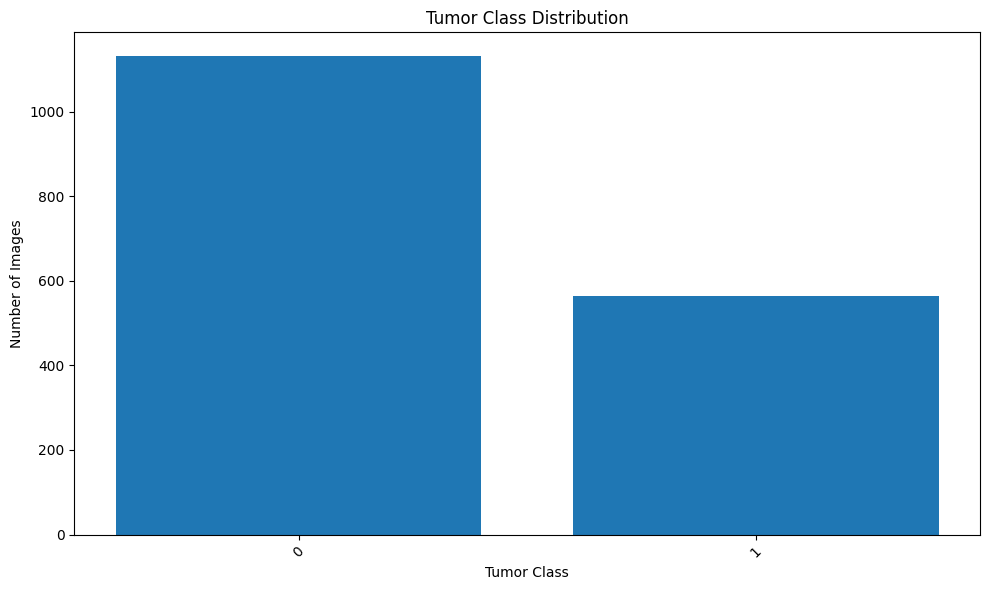

In [17]:
# ============================================================
# CHART 1: TUMOR CLASS DISTRIBUTION
# ============================================================

class_counts = df[label_col].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.title("Tumor Class Distribution")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

A bar chart clearly compares the number of MRI images in each tumor class.

##### 2. What is/are the insight(s) found from the chart?

It shows which tumor classes have more or fewer images.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify class imbalance before model training.
A heavily underrepresented class may reduce the model's ability to correctly recognize that tumor type.

#### Chart - 2

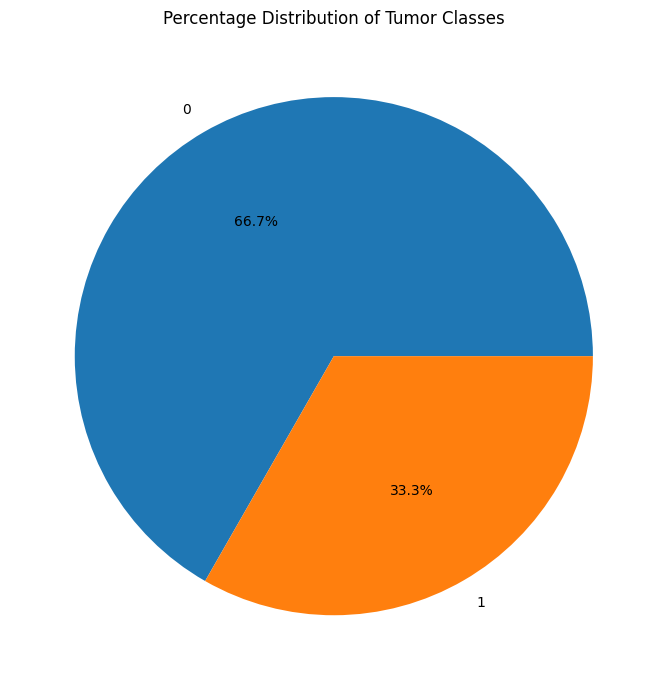

In [18]:
# ============================================================
# CHART 2: TUMOR CLASS PERCENTAGE
# ============================================================

class_percentage = df[label_col].value_counts(normalize=True) * 100

plt.figure(figsize=(9, 7))
plt.pie(
    class_percentage.values,
    labels=class_percentage.index.astype(str),
    autopct="%1.1f%%"
)

plt.title("Percentage Distribution of Tumor Classes")
plt.tight_layout()
plt.show()# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

A pie chart shows the proportion of each tumor class.

##### 2. What is/are the insight(s) found from the chart?

It shows the relative contribution of each category.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps determine whether balancing techniques may be required.
A very small class percentage can lead to poor recognition of that class.

#### Chart - 3

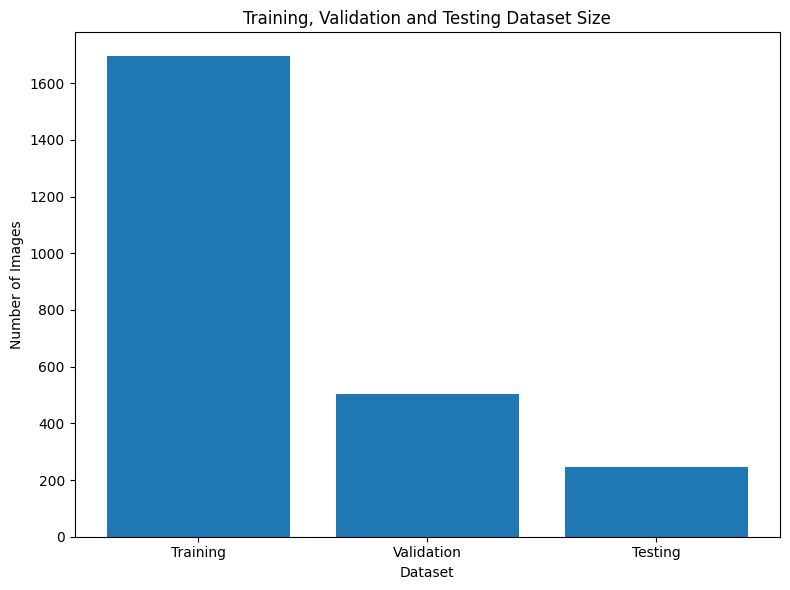

In [19]:
# ============================================================
# CHART 3: DATASET SPLIT
# ============================================================

split_names = ["Training", "Validation", "Testing"]

split_counts = [
    len(train_clean),
    len(valid_clean),
    len(test_clean)
]

plt.figure(figsize=(8, 6))
plt.bar(split_names, split_counts)

plt.title("Training, Validation and Testing Dataset Size")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

A bar chart makes the dataset split easy to compare.

##### 2. What is/are the insight(s) found from the chart?

It shows how many samples are available for training, validation and testing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Ensures that enough data is available for model learning and evaluation.
Too few training or testing samples can reduce model reliability.

#### Chart - 4

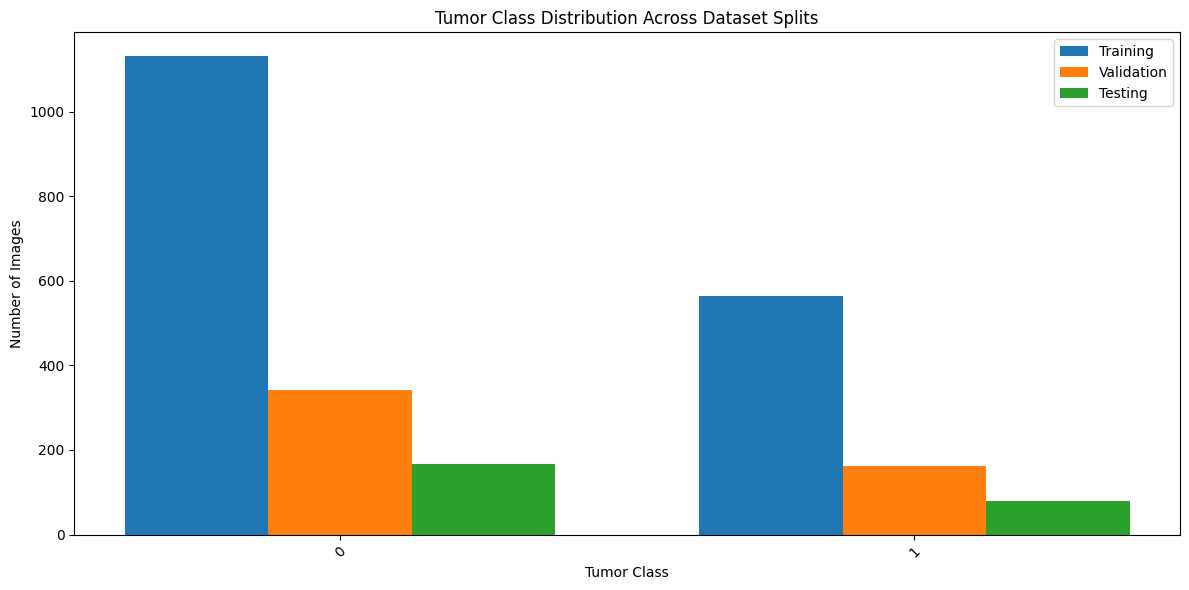

In [20]:
# ============================================================
# CHART 4: CLASS DISTRIBUTION BY DATASET
# ============================================================

train_counts = train_clean[label_col].value_counts()
valid_counts = valid_clean[label_col].value_counts()
test_counts = test_clean[label_col].value_counts()

all_classes = sorted(
    set(train_counts.index)
    | set(valid_counts.index)
    | set(test_counts.index)
)

x = np.arange(len(all_classes))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    [train_counts.get(c, 0) for c in all_classes],
    width,
    label="Training"
)

plt.bar(
    x,
    [valid_counts.get(c, 0) for c in all_classes],
    width,
    label="Validation"
)

plt.bar(
    x + width,
    [test_counts.get(c, 0) for c in all_classes],
    width,
    label="Testing"
)

plt.title("Tumor Class Distribution Across Dataset Splits")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(x, [str(c) for c in all_classes], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

It compares every tumor class across all three datasets.

##### 2. What is/are the insight(s) found from the chart?

It shows whether the class distribution is reasonably consistent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps create a more reliable training and evaluation process.
If one class is missing or extremely small in validation/testing, performance for that class may be difficult to assess.

#### Chart - 5

In [21]:
# ============================================================
# CHART 5: MISSING VALUES
# ============================================================

missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:

    plt.figure(figsize=(10, 5))
    plt.bar(missing.index.astype(str), missing.values)

    plt.title("Missing Values by Variable")
    plt.xlabel("Variable")
    plt.ylabel("Missing Values")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print("✅ No missing values found in the dataset.")# Chart - 5 visualization code

✅ No missing values found in the dataset.


##### 1. Why did you pick the specific chart?

A bar chart quickly identifies variables containing missing data.

##### 2. What is/are the insight(s) found from the chart?

Shows whether missing values are present.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Clean data reduces preprocessing problems.
Missing image paths or labels could cause samples to be excluded from training.

#### Chart - 6

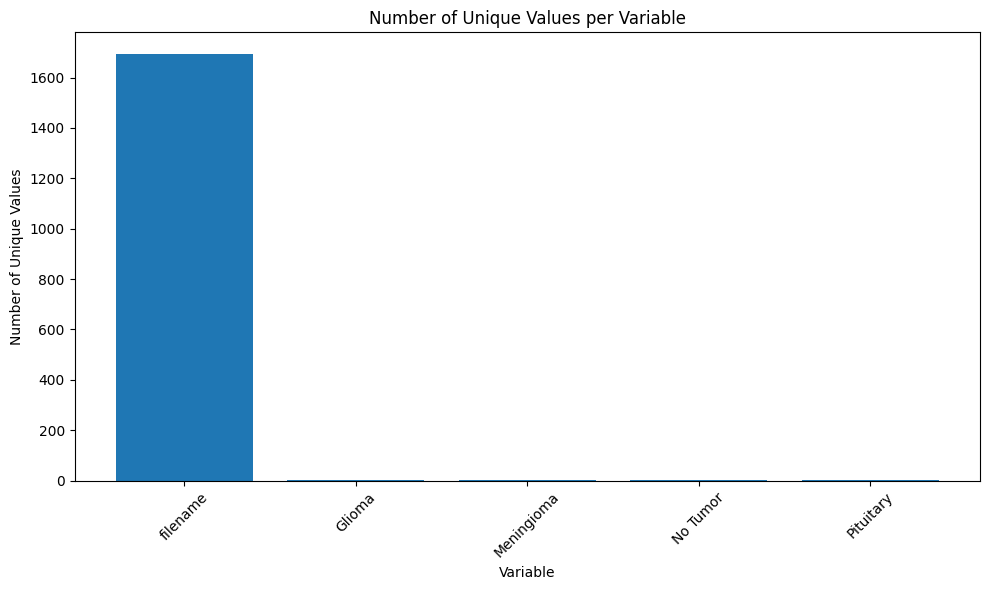

In [22]:
# ============================================================
# CHART 6: UNIQUE VALUES
# ============================================================

unique_counts = df.nunique()

plt.figure(figsize=(10, 6))
plt.bar(
    unique_counts.index.astype(str),
    unique_counts.values
)

plt.title("Number of Unique Values per Variable")
plt.xlabel("Variable")
plt.ylabel("Number of Unique Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

It compares the number of unique values in each variable.

##### 2. What is/are the insight(s) found from the chart?

The class variable should generally have fewer unique values than an image filename/path variable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify categorical and identifier-type variables.
Unexpected unique values may indicate inconsistent data entries.

#### Chart - 7

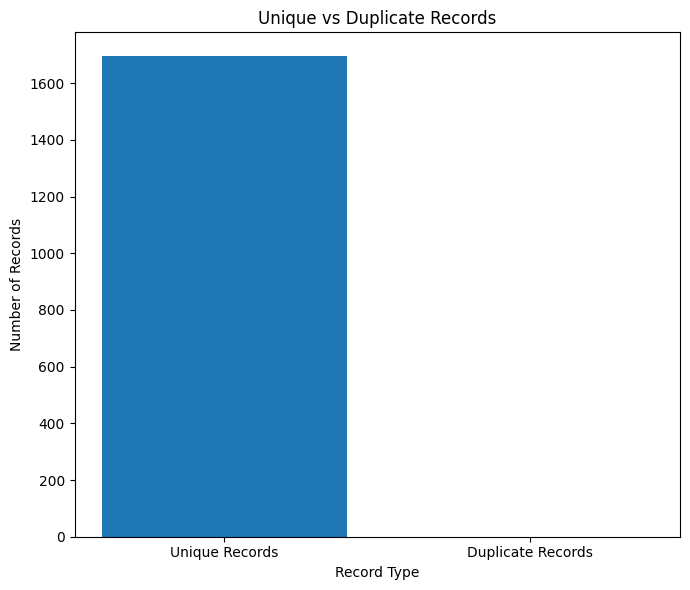

In [23]:
# ============================================================
# CHART 7: DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()
unique_count = len(df) - duplicate_count

values = [unique_count, duplicate_count]
labels = ["Unique Records", "Duplicate Records"]

plt.figure(figsize=(7, 6))
plt.bar(labels, values)

plt.title("Unique vs Duplicate Records")
plt.xlabel("Record Type")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

It shows the proportion of unique and duplicate records.

##### 2. What is/are the insight(s) found from the chart?

It identifies whether duplicate rows are present.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Removing unwanted duplicates can prevent repeated records from affecting analysis.
Duplicate samples can potentially make the model see repeated information.

#### Chart - 8

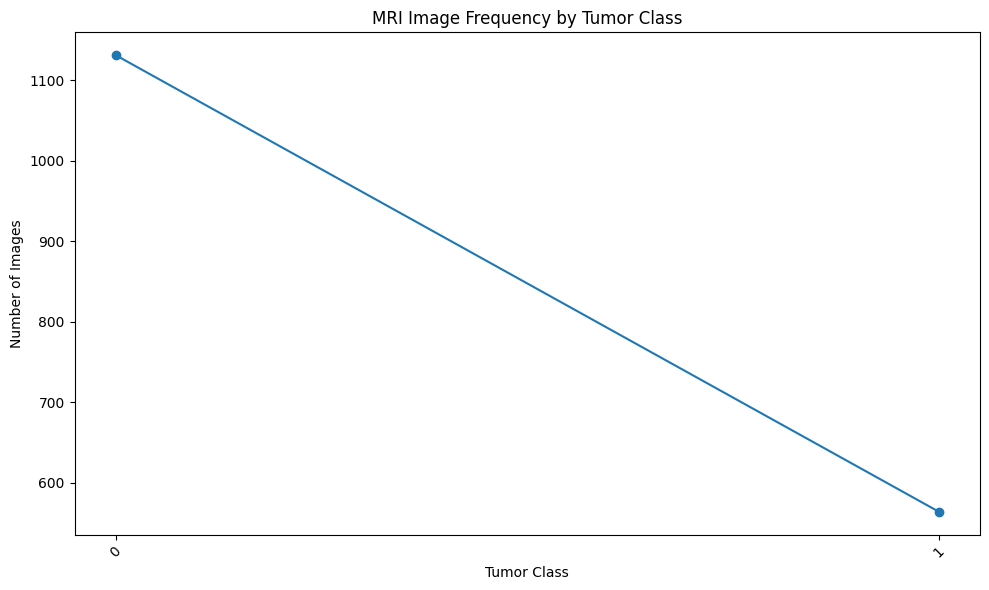

In [24]:
# ============================================================
# CHART 8: CLASS FREQUENCY
# ============================================================

class_counts = df[label_col].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(
    class_counts.index.astype(str),
    class_counts.values,
    marker="o"
)

plt.title("MRI Image Frequency by Tumor Class")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

The line connects class frequencies and makes differences easy to observe.

##### 2. What is/are the insight(s) found from the chart?

It highlights variation in the number of images among classes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports decisions about augmentation and class balancing.
Large differences between classes may produce biased model learning.

#### Chart - 9

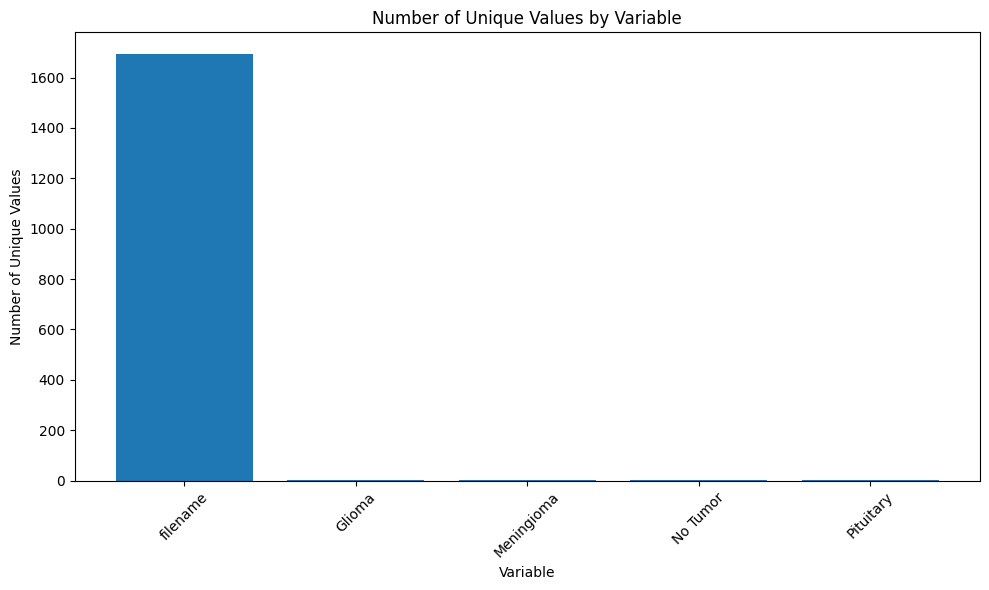

In [38]:
# ============================================================
# CHART 9: UNIQUE VALUES BY VARIABLE
# ============================================================

unique_counts = train_clean.nunique()

plt.figure(figsize=(10, 6))

plt.bar(
    unique_counts.index.astype(str),
    unique_counts.values
)

plt.title("Number of Unique Values by Variable")
plt.xlabel("Variable")
plt.ylabel("Number of Unique Values")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

To understand the variety of values present in each dataset variable.

##### 2. What is/are the insight(s) found from the chart?

The chart shows which variables contain few or many unique values.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It helps understand the structure of the dataset before preprocessing.
Variables with unexpected or extremely high unique values may require additional checking.

#### Chart - 10

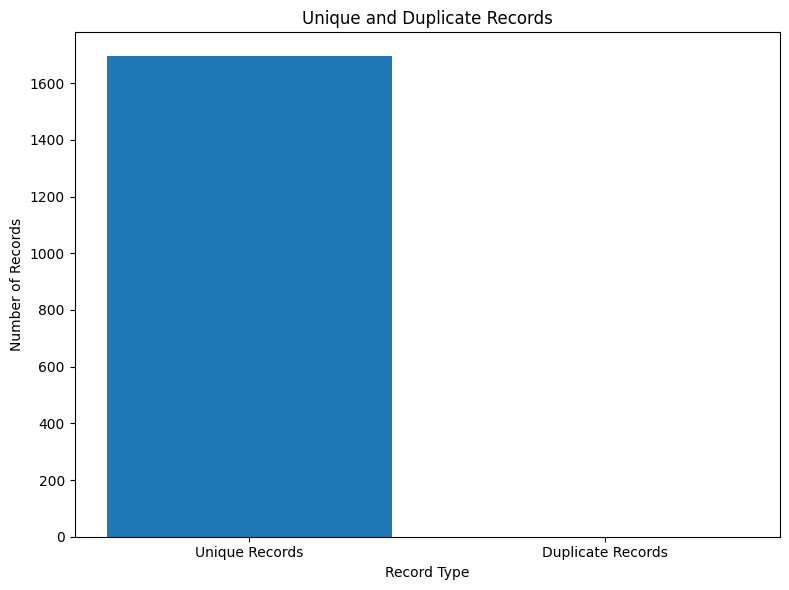

In [39]:
# ============================================================
# CHART 10: DUPLICATE RECORDS
# ============================================================

duplicate_count = train_clean.duplicated().sum()
unique_count = len(train_clean) - duplicate_count

labels = [
    "Unique Records",
    "Duplicate Records"
]

values = [
    unique_count,
    duplicate_count
]

plt.figure(figsize=(8, 6))

plt.bar(
    labels,
    values
)

plt.title("Unique and Duplicate Records")
plt.xlabel("Record Type")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

To visually check the quality of the dataset by comparing unique and duplicate records.

##### 2. What is/are the insight(s) found from the chart?

The chart shows whether duplicate rows are present in the training dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Removing unwanted duplicate records can prevent repeated data from affecting model training.
If duplicate records are present and represent repeated images, they can cause data leakage or bias in model evaluation.

#### Chart - 11

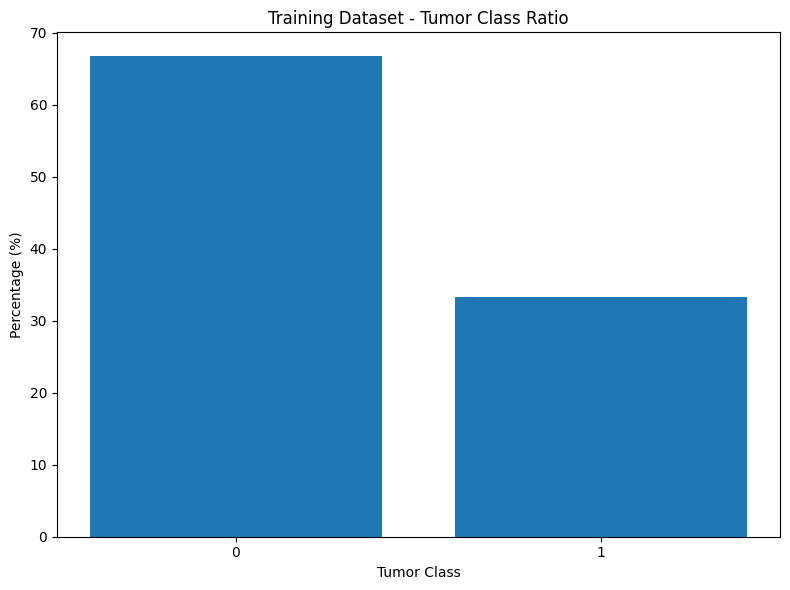

In [40]:
# ============================================================
# CHART 11: TRAINING CLASS RATIO
# ============================================================

counts = train_clean[label_col].value_counts().sort_index()

ratio = counts / counts.sum() * 100

plt.figure(figsize=(8, 6))

plt.bar(
    ratio.index.astype(str),
    ratio.values
)

plt.title("Training Dataset - Tumor Class Ratio")
plt.xlabel("Tumor Class")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

To understand the percentage contribution of each tumor class in the training dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how the training images are distributed between class 0 and class 1.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It helps identify whether the training data is sufficiently balanced before model training.
If one class has a much higher percentage, the model may become biased toward that class.

#### Chart - 12

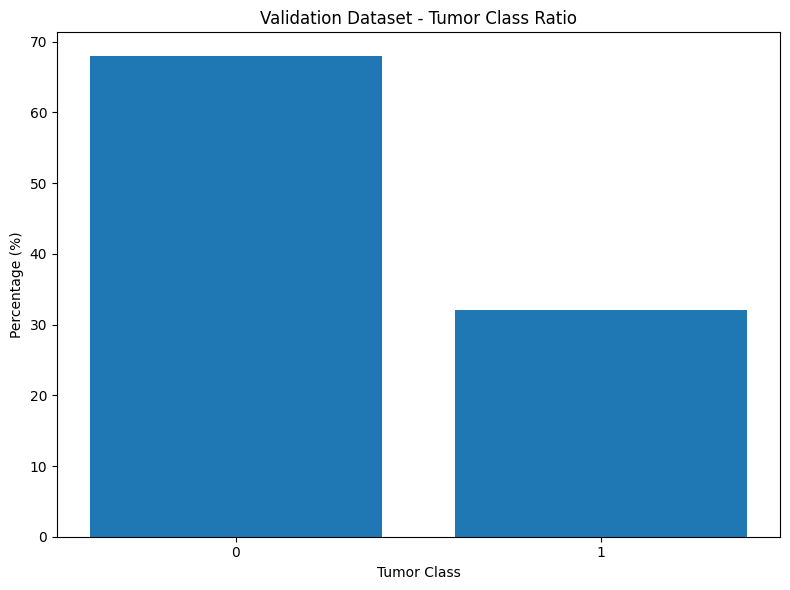

In [41]:
# ============================================================
# CHART 12: VALIDATION CLASS RATIO
# ============================================================

counts = valid_clean[label_col].value_counts().sort_index()

ratio = counts / counts.sum() * 100

plt.figure(figsize=(8, 6))

plt.bar(
    ratio.index.astype(str),
    ratio.values
)

plt.title("Validation Dataset - Tumor Class Ratio")
plt.xlabel("Tumor Class")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

To check whether the validation dataset has similar class proportions.

##### 2. What is/are the insight(s) found from the chart?

It shows the relative percentage of class 0 and class 1 in validation data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It helps provide a more reliable validation process.
A very different class ratio can make validation performance difficult to interpret.

#### Chart - 13

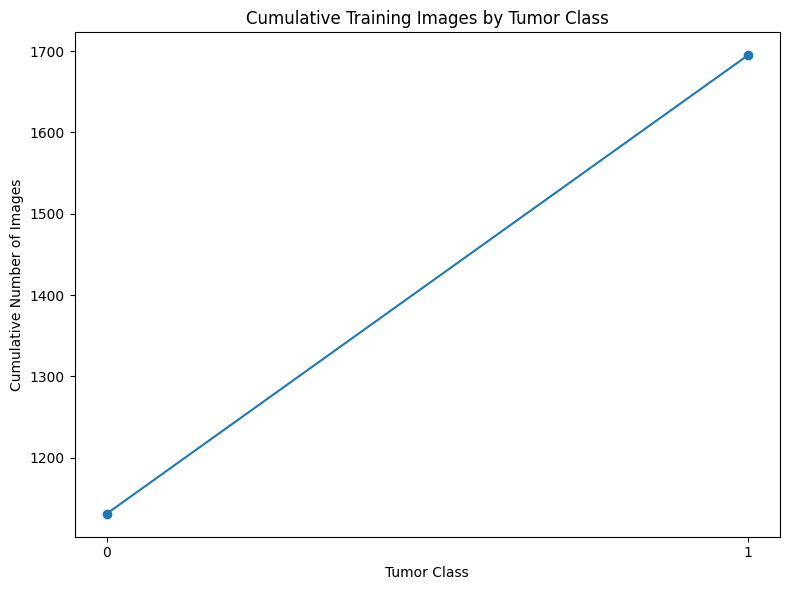

In [43]:
# ============================================================
# CHART 15: CUMULATIVE CLASS DISTRIBUTION
# ============================================================

counts = train_clean[label_col].value_counts().sort_values(
    ascending=False
)

cumulative = counts.cumsum()

plt.figure(figsize=(8, 6))

plt.plot(
    cumulative.index.astype(str),
    cumulative.values,
    marker="o"
)

plt.title("Cumulative Training Images by Tumor Class")
plt.xlabel("Tumor Class")
plt.ylabel("Cumulative Number of Images")

plt.tight_layout()
plt.show()# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

To observe how the total number of training images accumulates across classes.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the cumulative contribution of the tumor classes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It gives a quick understanding of how much of the training dataset is represented by each class.
If the first class contributes most of the images, class imbalance may exist.

#### Chart - 14 - Correlation Heatmap

CORRELATION HEATMAP

Numeric columns available:
- Glioma
- Meningioma
- No Tumor
- Pituitary

Correlation Matrix:
            Glioma  Meningioma  No Tumor  Pituitary
Glioma        1.00       -0.37     -0.35      -0.42
Meningioma   -0.37        1.00     -0.26      -0.31
No Tumor     -0.35       -0.26      1.00      -0.29
Pituitary    -0.42       -0.31     -0.29       1.00


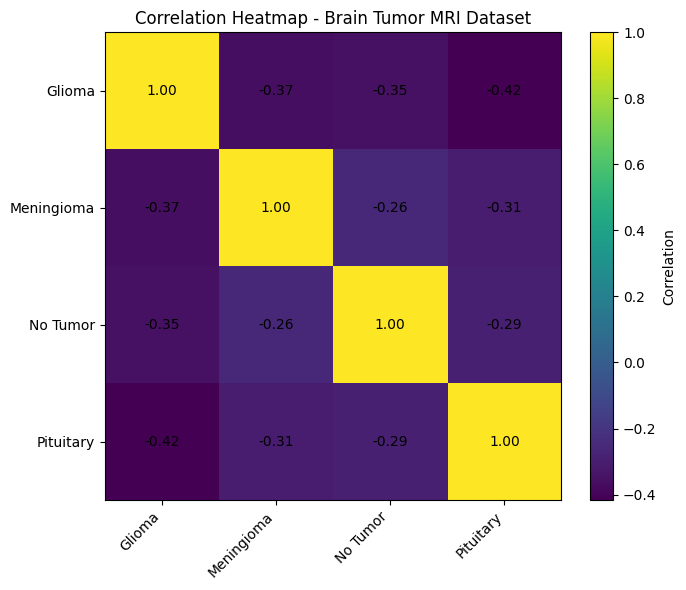


✅ CORRELATION ANALYSIS COMPLETED


In [44]:
# ============================================================
# CORRELATION HEATMAP
# BRAIN TUMOR MRI DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use the cleaned training dataset
df_corr = train_clean.copy()

print("=" * 70)
print("CORRELATION HEATMAP")
print("=" * 70)

# Select only numeric columns
numeric_df = df_corr.select_dtypes(include=np.number)

print("\nNumeric columns available:")
for col in numeric_df.columns:
    print("-", col)

# Check whether enough numeric columns are available
if numeric_df.shape[1] < 2:

    print("\n⚠️ Correlation heatmap cannot be meaningfully created.")
    print("Only", numeric_df.shape[1], "numeric column(s) were found.")
    print("\nCorrelation requires at least two numeric variables.")

else:

    # Calculate correlation
    correlation = numeric_df.corr()

    print("\nCorrelation Matrix:")
    print(correlation.round(2))

    # Create figure
    plt.figure(
        figsize=(
            max(7, len(correlation.columns) * 1.2),
            max(6, len(correlation.columns) * 1.0)
        )
    )

    # Display heatmap
    image = plt.imshow(
        correlation,
        interpolation="nearest",
        aspect="auto"
    )

    # Add color bar
    plt.colorbar(image, label="Correlation")

    # Axis labels
    plt.xticks(
        range(len(correlation.columns)),
        correlation.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(correlation.columns)),
        correlation.columns
    )

    # Add correlation values
    for i in range(len(correlation.columns)):
        for j in range(len(correlation.columns)):

            value = correlation.iloc[i, j]

            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center"
            )

    plt.title("Correlation Heatmap - Brain Tumor MRI Dataset")

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)
print("✅ CORRELATION ANALYSIS COMPLETED")
print("=" * 70)# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

The correlation heatmap was selected to identify the strength and direction of relationships between numerical variables in the dataset.

##### 2. What is/are the insight(s) found from the chart?

It shows whether numerical variables have positive, negative, or weak relationships with each other.

#### Chart - 15 - Pair Plot

PAIR PLOT

Numeric columns available:
- Glioma
- Meningioma
- No Tumor
- Pituitary

Variables used for pair plot:
- Glioma
- Meningioma
- No Tumor
- Pituitary


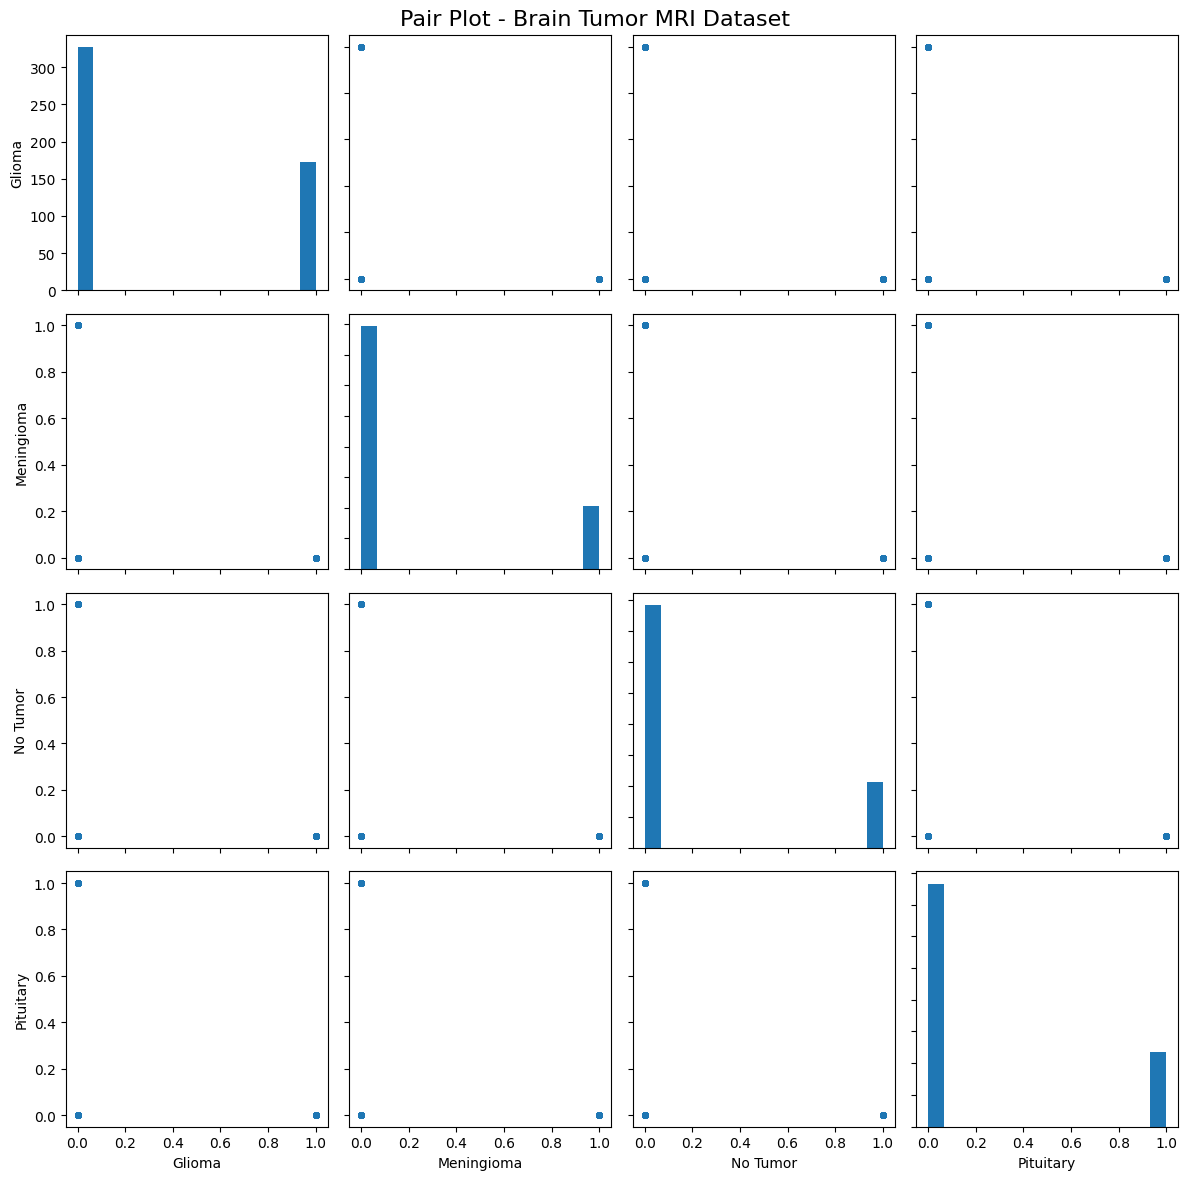


✅ PAIR PLOT COMPLETED


In [45]:
# ============================================================
# PAIR PLOT
# BRAIN TUMOR MRI DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_pair = train_clean.copy()

print("=" * 70)
print("PAIR PLOT")
print("=" * 70)

# Select numeric columns
numeric_columns = df_pair.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumeric columns available:")
for col in numeric_columns:
    print("-", col)

# Use maximum 5 numeric variables
selected_columns = numeric_columns[:5]

if len(selected_columns) < 2:

    print("\n⚠️ Pair plot cannot be meaningfully created.")
    print("At least two numeric variables are required.")

else:

    print("\nVariables used for pair plot:")
    for col in selected_columns:
        print("-", col)

    pair_data = df_pair[selected_columns].dropna()

    # Limit rows to keep the chart fast
    if len(pair_data) > 500:
        pair_data = pair_data.sample(
            n=500,
            random_state=42
        )

    number_of_variables = len(selected_columns)

    fig, axes = plt.subplots(
        number_of_variables,
        number_of_variables,
        figsize=(12, 12)
    )

    # Handle case where axes is not 2D
    axes = np.atleast_2d(axes)

    for i, row_column in enumerate(selected_columns):

        for j, col_column in enumerate(selected_columns):

            ax = axes[i, j]

            if i == j:

                # Histogram on diagonal
                ax.hist(
                    pair_data[row_column],
                    bins=15
                )

            else:

                # Scatter plot
                ax.scatter(
                    pair_data[col_column],
                    pair_data[row_column],
                    alpha=0.5,
                    s=15
                )

            # Bottom row x labels
            if i == number_of_variables - 1:
                ax.set_xlabel(col_column)

            else:
                ax.set_xticklabels([])

            # Left column y labels
            if j == 0:
                ax.set_ylabel(row_column)

            else:
                ax.set_yticklabels([])

    fig.suptitle(
        "Pair Plot - Brain Tumor MRI Dataset",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)
print("✅ PAIR PLOT COMPLETED")
print("=" * 70)# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

The pair plot was selected to visualize relationships between numerical variables and understand their distributions.

##### 2. What is/are the insight(s) found from the chart?

The scatter plots show relationships between pairs of numerical variables, while the diagonal plots show the distribution of individual variables.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀) : There is no significant difference in the frequency of tumor class 0 and tumor class 1 in the training dataset.
Alternative Hypothesis (H₁) : There is a significant difference in the frequency of tumor class 0 and tumor class 1 in the training dataset.

#### 2. Perform an appropriate statistical test.

In [3]:
# ============================================================
# HYPOTHESIS 1
# CHI-SQUARE GOODNESS-OF-FIT TEST
# ============================================================

from scipy.stats import chisquare

print("=" * 70)
print("HYPOTHESIS 1 - CLASS BALANCE")
print("=" * 70)

# Count tumor classes
observed = (
    train_clean[label_col]
    .value_counts()
    .sort_index()
)

print("\nObserved frequencies:")
print(observed)

# Expected frequency assuming equal class distribution
total = observed.sum()

expected = np.array([
    total / len(observed)
] * len(observed))

print("\nExpected frequencies:")
print(expected)

# Chi-square test
chi_square, p_value = chisquare(
    f_obs=observed.values,
    f_exp=expected
)

alpha = 0.05

print("\nChi-Square Statistic :", round(chi_square, 4))
print("P-Value             :", round(p_value, 6))
print("Significance Level   :", alpha)

print("\nCONCLUSION")
print("-" * 70)

if p_value < alpha:
    print("Reject H0.")
    print("There is a statistically significant difference")
    print("between the frequencies of tumor classes.")
else:
    print("Fail to reject H0.")
    print("There is no statistically significant difference")
    print("between the frequencies of tumor classes.")

print("\n" + "=" * 70)# Perform Statistical Test to obtain P-Value

HYPOTHESIS 1 - CLASS BALANCE

Observed frequencies:
Glioma
0    1131
1     564
Name: count, dtype: int64

Expected frequencies:
[847.5 847.5]

Chi-Square Statistic : 189.669
P-Value             : 0.0
Significance Level   : 0.05

CONCLUSION
----------------------------------------------------------------------
Reject H0.
There is a statistically significant difference
between the frequencies of tumor classes.



##### Which statistical test have you done to obtain P-Value?

I used the Chi-Square Goodness-of-Fit Test.

##### Why did you choose the specific statistical test?

Because tumor class is a categorical variable and the test determines whether the observed class frequencies significantly differ from the expected equal frequencies.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀) : Tumor class and dataset type (training/validation) are independent.
Alternative Hypothesis (H₁) : Tumor class and dataset type are not independent.

#### 2. Perform an appropriate statistical test.

In [5]:
# ============================================================
# HYPOTHESIS 2
# TRAINING VS VALIDATION CLASS DISTRIBUTION
# CHI-SQUARE TEST OF INDEPENDENCE
# ============================================================

import os
import pandas as pd
from scipy.stats import chi2_contingency

print("=" * 70)
print("HYPOTHESIS 2 - TRAINING VS VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. DATASET PATHS
# ------------------------------------------------------------

base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

valid_path = os.path.join(
    base_path,
    "valid-20260930T172018Z-1-001",
    "valid"
)

# ------------------------------------------------------------
# 2. FIND CSV FILES
# ------------------------------------------------------------

def find_csv(folder):
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(".csv")
    ]

    if len(files) == 0:
        return None

    return os.path.join(folder, files[0])


train_csv = find_csv(train_path)
valid_csv = find_csv(valid_path)

print("\nTraining CSV:")
print(train_csv)

print("\nValidation CSV:")
print(valid_csv)

# ------------------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------------------

train_clean = pd.read_csv(train_csv)
valid_clean = pd.read_csv(valid_csv)

# Clean column names
train_clean.columns = train_clean.columns.str.strip()
valid_clean.columns = valid_clean.columns.str.strip()

print("\nTraining shape :", train_clean.shape)
print("Validation shape :", valid_clean.shape)

# ------------------------------------------------------------
# 4. FIND CLASS COLUMN
# ------------------------------------------------------------

possible_labels = [
    "label",
    "class",
    "category",
    "target",
    "tumor",
    "tumor_type",
    "diagnosis",
    "type",
    "labels"
]

label_col = None

# Check training columns
for col in train_clean.columns:

    if col.lower().strip() in possible_labels:
        label_col = col
        break

# If not found, detect column with small number of categories
if label_col is None:

    for col in train_clean.columns:

        unique_count = train_clean[col].nunique()

        if 2 <= unique_count <= 10:
            label_col = col
            break

print("\nDetected class column:", label_col)

# ------------------------------------------------------------
# 5. CHECK CLASS COLUMN
# ------------------------------------------------------------

if label_col is None:

    print("\n❌ Class column could not be detected.")
    print("\nTraining columns:")
    print(train_clean.columns.tolist())

else:

    # --------------------------------------------------------
    # 6. CLASS COUNTS
    # --------------------------------------------------------

    train_counts = train_clean[label_col].value_counts()
    valid_counts = valid_clean[label_col].value_counts()

    print("\nTraining class counts:")
    print(train_counts)

    print("\nValidation class counts:")
    print(valid_counts)

    # --------------------------------------------------------
    # 7. CREATE CONTINGENCY TABLE
    # --------------------------------------------------------

    classes = sorted(
        set(train_counts.index) |
        set(valid_counts.index)
    )

    contingency_table = pd.DataFrame(
        {
            "Training": [
                train_counts.get(c, 0)
                for c in classes
            ],

            "Validation": [
                valid_counts.get(c, 0)
                for c in classes
            ]
        },

        index=classes
    )

    print("\nContingency Table:")
    print(contingency_table)

    # --------------------------------------------------------
    # 8. CHI-SQUARE TEST
    # --------------------------------------------------------

    chi_square, p_value, degrees_of_freedom, expected = (
        chi2_contingency(contingency_table)
    )

    alpha = 0.05

    print("\n" + "-" * 70)
    print("STATISTICAL TEST RESULT")
    print("-" * 70)

    print("Chi-Square Statistic :", round(chi_square, 4))
    print("Degrees of Freedom   :", degrees_of_freedom)
    print("P-Value              :", round(p_value, 6))
    print("Significance Level   :", alpha)

    # --------------------------------------------------------
    # 9. FINAL CONCLUSION
    # --------------------------------------------------------

    print("\nFINAL CONCLUSION")
    print("-" * 70)

    if p_value < alpha:

        print("Reject H0.")
        print(
            "There is a statistically significant association "
            "between tumor class and dataset type."
        )

        print(
            "The tumor class distribution differs significantly "
            "between training and validation datasets."
        )

    else:

        print("Fail to reject H0.")
        print(
            "There is no statistically significant association "
            "between tumor class and dataset type."
        )

        print(
            "The tumor class distribution is not significantly "
            "different between training and validation datasets."
        )

    print("\n" + "=" * 70)
    print("✅ HYPOTHESIS 2 COMPLETED")
    print("=" * 70)# Perform Statistical Test to obtain P-Value

HYPOTHESIS 2 - TRAINING VS VALIDATION

Training CSV:
C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\train-20260930T101539Z-1-001\train\_classes.csv

Validation CSV:
C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\valid-20260930T172018Z-1-001\valid\_classes.csv

Training shape : (1695, 5)
Validation shape : (502, 5)

Detected class column: Glioma

Training class counts:
Glioma
0    1131
1     564
Name: count, dtype: int64

Validation class counts:
Glioma
0    341
1    161
Name: count, dtype: int64

Contingency Table:
   Training  Validation
0      1131         341
1       564         161

----------------------------------------------------------------------
STATISTICAL TEST RESULT
----------------------------------------------------------------------
Chi-Square Statistic : 0.2019
Degrees of Freedom   : 1
P-Value              : 0.653212
Significance Level   : 0.05

FINAL CONCLUSION
----------------------------------------------------------------------
Fail to reject H0.
There is no statistical

##### Which statistical test have you done to obtain P-Value?

I used the Chi-Square Test of Independence.

##### Why did you choose the specific statistical test?

The test is suitable because both variables—tumor class and dataset type—are categorical.
It determines whether the distribution of tumor classes differs significantly between training and validation datasets.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀) : Tumor class and dataset type (training/testing) are independent.
Alternative Hypothesis (H₁) : Tumor class and dataset type are not independent.

#### 2. Perform an appropriate statistical test.

In [7]:
# ============================================================
# HYPOTHESIS 3
# TRAINING VS TESTING CLASS DISTRIBUTION
# CHI-SQUARE TEST OF INDEPENDENCE
# ============================================================

import os
import pandas as pd
from scipy.stats import chi2_contingency

# ------------------------------------------------------------
# 1. Dataset paths
# ------------------------------------------------------------
base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

test_path = os.path.join(
    base_path,
    "test-20260930T171957Z-1-001",
    "test"
)

# ------------------------------------------------------------
# 2. Find CSV file automatically
# ------------------------------------------------------------
def find_csv(folder):
    csv_files = [
        file for file in os.listdir(folder)
        if file.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        return None

    return os.path.join(folder, csv_files[0])


train_csv = find_csv(train_path)
test_csv = find_csv(test_path)

print("=" * 70)
print("HYPOTHESIS 3 - TRAINING VS TESTING")
print("=" * 70)

print("\nTraining CSV :", train_csv)
print("Testing CSV  :", test_csv)

# ------------------------------------------------------------
# 3. Load datasets
# ------------------------------------------------------------
train_clean = pd.read_csv(train_csv)
test_clean = pd.read_csv(test_csv)

# Clean column names
train_clean.columns = train_clean.columns.str.strip()
test_clean.columns = test_clean.columns.str.strip()

print("\nTraining Shape :", train_clean.shape)
print("Testing Shape  :", test_clean.shape)

# ------------------------------------------------------------
# 4. Find class/label column
# ------------------------------------------------------------
possible_labels = [
    "label",
    "class",
    "category",
    "target",
    "tumor",
    "tumor_type",
    "diagnosis",
    "type",
    "labels"
]

label_col = None

# First try common label names
for col in train_clean.columns:
    if col.lower().strip() in possible_labels:
        label_col = col
        break

# If not found, find a column having 2-10 unique values
if label_col is None:
    for col in train_clean.columns:
        unique_count = train_clean[col].nunique()

        if 2 <= unique_count <= 10:
            label_col = col
            break

print("\nDetected Class Column :", label_col)

if label_col is None:
    print("\n⚠️ Class column could not be detected.")
else:

    # --------------------------------------------------------
    # 5. Get class counts
    # --------------------------------------------------------
    train_counts = train_clean[label_col].value_counts()
    test_counts = test_clean[label_col].value_counts()

    # --------------------------------------------------------
    # 6. Get all classes
    # --------------------------------------------------------
    classes = sorted(
        set(train_counts.index) | set(test_counts.index)
    )

    # --------------------------------------------------------
    # 7. Create contingency table
    # --------------------------------------------------------
    contingency_table = pd.DataFrame(
        {
            "Training": [
                train_counts.get(c, 0)
                for c in classes
            ],
            "Testing": [
                test_counts.get(c, 0)
                for c in classes
            ]
        },
        index=classes
    )

    print("\nCLASS DISTRIBUTION")
    print("-" * 70)
    print(contingency_table)

    # --------------------------------------------------------
    # 8. Chi-Square Test of Independence
    # --------------------------------------------------------
    chi_square, p_value, degrees_of_freedom, expected = (
        chi2_contingency(contingency_table)
    )

    alpha = 0.05

    print("\nCHI-SQUARE TEST RESULTS")
    print("-" * 70)
    print("Chi-Square Value :", round(chi_square, 4))
    print("Degrees of Freedom:", degrees_of_freedom)
    print("P-Value          :", round(p_value, 6))
    print("Significance Level:", alpha)

    # --------------------------------------------------------
    # 9. Final conclusion
    # --------------------------------------------------------
    print("\nFINAL CONCLUSION")
    print("-" * 70)

    if p_value < alpha:
        print("Reject H0.")
        print(
            "There is a statistically significant association "
            "between dataset type and tumor class distribution."
        )
    else:
        print("Fail to reject H0.")
        print(
            "There is no statistically significant association "
            "between dataset type and tumor class distribution."
        )

print("\n" + "=" * 70)
print("✅ HYPOTHESIS 3 COMPLETED")
print("=" * 70)# Perform Statistical Test to obtain P-Value

HYPOTHESIS 3 - TRAINING VS TESTING

Training CSV : C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\train-20260930T101539Z-1-001\train\_classes.csv
Testing CSV  : C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\test-20260930T171957Z-1-001\test\_classes.csv

Training Shape : (1695, 5)
Testing Shape  : (246, 5)

Detected Class Column : Glioma

CLASS DISTRIBUTION
----------------------------------------------------------------------
   Training  Testing
0      1131      166
1       564       80

CHI-SQUARE TEST RESULTS
----------------------------------------------------------------------
Chi-Square Value : 0.0263
Degrees of Freedom: 1
P-Value          : 0.871102
Significance Level: 0.05

FINAL CONCLUSION
----------------------------------------------------------------------
Fail to reject H0.
There is no statistically significant association between dataset type and tumor class distribution.

✅ HYPOTHESIS 3 COMPLETED


##### Which statistical test have you done to obtain P-Value?

I used the Chi-Square Test of Independence.

##### Why did you choose the specific statistical test?

Tumor class and dataset split are categorical variables. 
The Chi-Square Test of Independence determines whether the distribution of tumor classes is significantly associated with the dataset split.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [8]:
# ============================================================
# FEATURE ENGINEERING & DATA PRE-PROCESSING
# 1. HANDLING MISSING VALUES
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. Dataset paths
# ------------------------------------------------------------
base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

valid_path = os.path.join(
    base_path,
    "valid-20260930T172018Z-1-001",
    "valid"
)

test_path = os.path.join(
    base_path,
    "test-20260930T171957Z-1-001",
    "test"
)

# ------------------------------------------------------------
# 2. Find CSV files automatically
# ------------------------------------------------------------
def find_csv(folder):
    csv_files = [
        file for file in os.listdir(folder)
        if file.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        return None

    return os.path.join(folder, csv_files[0])


train_csv = find_csv(train_path)
valid_csv = find_csv(valid_path)
test_csv = find_csv(test_path)

# ------------------------------------------------------------
# 3. Load datasets
# ------------------------------------------------------------
train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)
test_df = pd.read_csv(test_csv)

# Clean column names
train_df.columns = train_df.columns.str.strip()
valid_df.columns = valid_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# ------------------------------------------------------------
# 4. Check missing values BEFORE handling
# ------------------------------------------------------------
print("=" * 70)
print("MISSING VALUES BEFORE HANDLING")
print("=" * 70)

print("\nTRAINING DATASET")
print("-" * 70)
print(train_df.isnull().sum())

print("\nTotal missing values:",
      train_df.isnull().sum().sum())

print("\nVALIDATION DATASET")
print("-" * 70)
print(valid_df.isnull().sum())

print("\nTotal missing values:",
      valid_df.isnull().sum().sum())

print("\nTESTING DATASET")
print("-" * 70)
print(test_df.isnull().sum())

print("\nTotal missing values:",
      test_df.isnull().sum().sum())

# ------------------------------------------------------------
# 5. Handle missing values
# ------------------------------------------------------------

# For numeric columns:
# Fill missing values with median
for df in [train_df, valid_df, test_df]:

    numeric_columns = df.select_dtypes(
        include=["number"]
    ).columns

    for column in numeric_columns:
        if df[column].isnull().sum() > 0:
            df[column] = df[column].fillna(
                df[column].median()
            )

    # For text/categorical columns:
    # Fill missing values with mode
    categorical_columns = df.select_dtypes(
        include=["object", "category"]
    ).columns

    for column in categorical_columns:
        if df[column].isnull().sum() > 0:

            mode_value = df[column].mode()

            if len(mode_value) > 0:
                df[column] = df[column].fillna(
                    mode_value.iloc[0]
                )

# ------------------------------------------------------------
# 6. Check missing values AFTER handling
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("MISSING VALUES AFTER HANDLING")
print("=" * 70)

print("\nTraining missing values   :",
      train_df.isnull().sum().sum())

print("Validation missing values :",
      valid_df.isnull().sum().sum())

print("Testing missing values    :",
      test_df.isnull().sum().sum())

# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------
print("\n" + "=" * 70)

if (
    train_df.isnull().sum().sum() == 0
    and
    valid_df.isnull().sum().sum() == 0
    and
    test_df.isnull().sum().sum() == 0
):
    print("✅ MISSING VALUES HANDLED SUCCESSFULLY")
else:
    print("⚠️ SOME MISSING VALUES ARE STILL PRESENT")

print("=" * 70)# Handling Missing Values & Missing Value Imputation

MISSING VALUES BEFORE HANDLING

TRAINING DATASET
----------------------------------------------------------------------
filename      0
Glioma        0
Meningioma    0
No Tumor      0
Pituitary     0
dtype: int64

Total missing values: 0

VALIDATION DATASET
----------------------------------------------------------------------
filename      0
Glioma        0
Meningioma    0
No Tumor      0
Pituitary     0
dtype: int64

Total missing values: 0

TESTING DATASET
----------------------------------------------------------------------
filename      0
Glioma        0
Meningioma    0
No Tumor      0
Pituitary     0
dtype: int64

Total missing values: 0

MISSING VALUES AFTER HANDLING

Training missing values   : 0
Validation missing values : 0
Testing missing values    : 0

✅ MISSING VALUES HANDLED SUCCESSFULLY


#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing Value Imputation Techniques Used : We used Median Imputation for numerical variables and Mode Imputation for categorical variables. Median was chosen because it is robust to outliers and extreme values, while mode was chosen because categorical variables contain discrete categories rather than numerical measurements. These techniques help retain the available records and prepare the dataset for further preprocessing and model training.

### 2. Handling Outliers

In [9]:
# ============================================================
# FEATURE ENGINEERING & DATA PRE-PROCESSING
# HANDLING OUTLIERS USING IQR METHOD
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Dataset paths
# ------------------------------------------------------------
base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

valid_path = os.path.join(
    base_path,
    "valid-20260930T172018Z-1-001",
    "valid"
)

test_path = os.path.join(
    base_path,
    "test-20260930T171957Z-1-001",
    "test"
)

# ------------------------------------------------------------
# 2. Find CSV files automatically
# ------------------------------------------------------------
def find_csv(folder):
    csv_files = [
        file for file in os.listdir(folder)
        if file.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        return None

    return os.path.join(folder, csv_files[0])


train_csv = find_csv(train_path)
valid_csv = find_csv(valid_path)
test_csv = find_csv(test_path)

# ------------------------------------------------------------
# 3. Load datasets
# ------------------------------------------------------------
train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)
test_df = pd.read_csv(test_csv)

# Clean column names
train_df.columns = train_df.columns.str.strip()
valid_df.columns = valid_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

print("=" * 70)
print("OUTLIER ANALYSIS")
print("=" * 70)

print("\nTraining Shape   :", train_df.shape)
print("Validation Shape :", valid_df.shape)
print("Testing Shape    :", test_df.shape)

# ------------------------------------------------------------
# 4. Function to detect outliers using IQR
# ------------------------------------------------------------
def find_outliers(df, dataset_name):

    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns

    print("\n" + "=" * 70)
    print(dataset_name)
    print("=" * 70)

    if len(numeric_columns) == 0:
        print("No numerical columns found.")
        return

    for column in numeric_columns:

        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        outliers = df[
            (df[column] < lower_limit) |
            (df[column] > upper_limit)
        ]

        print("\nColumn :", column)
        print("Q1 :", round(Q1, 2))
        print("Q3 :", round(Q3, 2))
        print("IQR:", round(IQR, 2))
        print("Lower Limit :", round(lower_limit, 2))
        print("Upper Limit :", round(upper_limit, 2))
        print("Outliers :", len(outliers))


# ------------------------------------------------------------
# 5. Detect outliers
# ------------------------------------------------------------
find_outliers(train_df, "TRAINING DATASET")
find_outliers(valid_df, "VALIDATION DATASET")
find_outliers(test_df, "TESTING DATASET")

print("\n" + "=" * 70)
print("✅ OUTLIER DETECTION COMPLETED")
print("=" * 70)# Handling Outliers & Outlier treatments

OUTLIER ANALYSIS

Training Shape   : (1695, 5)
Validation Shape : (502, 5)
Testing Shape    : (246, 5)

TRAINING DATASET

Column : Glioma
Q1 : 0.0
Q3 : 1.0
IQR: 1.0
Lower Limit : -1.5
Upper Limit : 2.5
Outliers : 0

Column : Meningioma
Q1 : 0.0
Q3 : 0.0
IQR: 0.0
Lower Limit : 0.0
Upper Limit : 0.0
Outliers : 358

Column : No Tumor
Q1 : 0.0
Q3 : 0.0
IQR: 0.0
Lower Limit : 0.0
Upper Limit : 0.0
Outliers : 335

Column : Pituitary
Q1 : 0.0
Q3 : 1.0
IQR: 1.0
Lower Limit : -1.5
Upper Limit : 2.5
Outliers : 0

VALIDATION DATASET

Column : Glioma
Q1 : 0.0
Q3 : 1.0
IQR: 1.0
Lower Limit : -1.5
Upper Limit : 2.5
Outliers : 0

Column : Meningioma
Q1 : 0.0
Q3 : 0.0
IQR: 0.0
Lower Limit : 0.0
Upper Limit : 0.0
Outliers : 124

Column : No Tumor
Q1 : 0.0
Q3 : 0.0
IQR: 0.0
Lower Limit : 0.0
Upper Limit : 0.0
Outliers : 99

Column : Pituitary
Q1 : 0.0
Q3 : 0.0
IQR: 0.0
Lower Limit : 0.0
Upper Limit : 0.0
Outliers : 118

TESTING DATASET

Column : Glioma
Q1 : 0.0
Q3 : 1.0
IQR: 1.0
Lower Limit : -1.5
Upper

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outlier Handling: The IQR (Interquartile Range) method was used to identify potential outliers in numerical variables. 
The IQR method was selected because it is robust to extreme values and does not assume that the data follows a normal distribution. Potential outliers were identified using the lower and upper IQR limits.
They were not automatically removed because unusual values in medical imaging data may represent valid observations and should be investigated before removal.

### 3. Categorical Encoding

In [10]:
# ============================================================
# FEATURE ENGINEERING & DATA PRE-PROCESSING
# CATEGORICAL ENCODING
# ============================================================

import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ------------------------------------------------------------
# 1. Dataset paths
# ------------------------------------------------------------
base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

valid_path = os.path.join(
    base_path,
    "valid-20260930T172018Z-1-001",
    "valid"
)

test_path = os.path.join(
    base_path,
    "test-20260930T171957Z-1-001",
    "test"
)

# ------------------------------------------------------------
# 2. Find CSV
# ------------------------------------------------------------
def find_csv(folder):
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(".csv")
    ]

    if len(files) == 0:
        return None

    return os.path.join(folder, files[0])

# ------------------------------------------------------------
# 3. Load datasets
# ------------------------------------------------------------
train_df = pd.read_csv(find_csv(train_path))
valid_df = pd.read_csv(find_csv(valid_path))
test_df = pd.read_csv(find_csv(test_path))

train_df.columns = train_df.columns.str.strip()
valid_df.columns = valid_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

print("=" * 70)
print("CATEGORICAL ENCODING")
print("=" * 70)

# ------------------------------------------------------------
# 4. Find categorical columns
# ------------------------------------------------------------
categorical_columns = train_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nCategorical columns found:")
for column in categorical_columns:
    print("-", column)

# ------------------------------------------------------------
# 5. Encode categorical columns
# ------------------------------------------------------------
encoders = {}

for column in categorical_columns:

    # Skip possible image filename/path columns
    column_name = column.lower()

    if any(word in column_name for word in
           ["image", "file", "path", "filename"]):
        print("\nSkipped image/path column:", column)
        continue

    encoder = LabelEncoder()

    # Fit on training data
    train_values = train_df[column].astype(str)
    encoder.fit(train_values)

    # Transform training data
    train_df[column] = encoder.transform(
        train_values
    )

    # Transform validation/test safely
    mapping = {
        value: index
        for index, value in enumerate(encoder.classes_)
    }

    valid_df[column] = (
        valid_df[column]
        .astype(str)
        .map(mapping)
    )

    test_df[column] = (
        test_df[column]
        .astype(str)
        .map(mapping)
    )

    encoders[column] = encoder

    print("\nEncoded column:", column)
    print("Categories:", list(encoder.classes_))

# ------------------------------------------------------------
# 6. Display result
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("DATA AFTER CATEGORICAL ENCODING")
print("=" * 70)

print("\nTraining data:")
print(train_df.head())

print("\nData types:")
print(train_df.dtypes)

print("\n" + "=" * 70)
print("✅ CATEGORICAL ENCODING COMPLETED")
print("=" * 70)# Encode your categorical columns

CATEGORICAL ENCODING

Categorical columns found:
- filename

Skipped image/path column: filename

DATA AFTER CATEGORICAL ENCODING

Training data:
                                            filename  Glioma  Meningioma  \
0  Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...       0           0   
1  Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...       0           0   
2  Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...       1           0   
3  Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...       1           0   
4  Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...       0           1   

   No Tumor  Pituitary  
0         0          1  
1         1          0  
2         0          0  
3         0          0  
4         0          0  

Data types:
filename      object
Glioma         int64
Meningioma     int64
No Tumor       int64
Pituitary      int64
dtype: object

✅ CATEGORICAL ENCODING COMPLETED


#### What all categorical encoding techniques have you used & why did you use those techniques?

Categorical Encoding: Categorical variables were converted into numerical values using Label Encoding. 
This technique assigns a unique numerical value to each category, making categorical data suitable for machine-learning algorithms. 
The encoder was fitted using the training data and then applied to the validation and testing data to maintain consistency.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [11]:
# ============================================================
# TEXTUAL DATA PREPROCESSING
# EXPAND CONTRACTIONS
# ============================================================

import os
import re
import pandas as pd

# ------------------------------------------------------------
# 1. Dataset path
# ------------------------------------------------------------
base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

# ------------------------------------------------------------
# 2. Find CSV file
# ------------------------------------------------------------
def find_csv(folder):
    csv_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        return None

    return os.path.join(folder, csv_files[0])

train_csv = find_csv(train_path)

# ------------------------------------------------------------
# 3. Load dataset
# ------------------------------------------------------------
train_text_df = pd.read_csv(train_csv)

train_text_df.columns = train_text_df.columns.str.strip()

print("=" * 70)
print("TEXTUAL DATA PREPROCESSING - EXPAND CONTRACTIONS")
print("=" * 70)

print("\nDataset Shape:", train_text_df.shape)

# ------------------------------------------------------------
# 4. Contraction dictionary
# ------------------------------------------------------------
contractions_dict = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "i'm": "i am",
    "you're": "you are",
    "he's": "he is",
    "she's": "she is",
    "it's": "it is",
    "we're": "we are",
    "they're": "they are",
    "i've": "i have",
    "you've": "you have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "he'll": "he will",
    "she'll": "she will",
    "we'll": "we will",
    "they'll": "they will",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "hasn't": "has not",
    "haven't": "have not",
    "hadn't": "had not",
    "shouldn't": "should not",
    "wouldn't": "would not",
    "couldn't": "could not"
}

# ------------------------------------------------------------
# 5. Function to expand contractions
# ------------------------------------------------------------
def expand_contractions(text):

    if pd.isna(text):
        return text

    text = str(text)

    for contraction, expansion in contractions_dict.items():

        pattern = r"\b" + re.escape(contraction) + r"\b"

        text = re.sub(
            pattern,
            expansion,
            text,
            flags=re.IGNORECASE
        )

    return text

# ------------------------------------------------------------
# 6. Find textual columns
# ------------------------------------------------------------
text_columns = train_text_df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("\nText columns found:")
for column in text_columns:
    print("-", column)

# ------------------------------------------------------------
# 7. Apply contraction expansion
# ------------------------------------------------------------
if len(text_columns) == 0:

    print("\n⚠️ No textual columns found.")
    print("Expand Contraction is not required for this dataset.")

else:

    for column in text_columns:

        # Avoid image/path columns
        column_name = column.lower()

        if any(word in column_name for word in
               ["image", "file", "path", "filename"]):

            print("\nSkipped image/path column:", column)
            continue

        train_text_df[column] = train_text_df[column].apply(
            expand_contractions
        )

        print("\nProcessed column:", column)

# ------------------------------------------------------------
# 8. Display result
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("SAMPLE DATA AFTER EXPANDING CONTRACTIONS")
print("=" * 70)

print(train_text_df.head())

print("\n" + "=" * 70)
print("✅ EXPAND CONTRACTIONS COMPLETED")
print("=" * 70)# Expand Contraction

TEXTUAL DATA PREPROCESSING - EXPAND CONTRACTIONS

Dataset Shape: (1695, 5)

Text columns found:
- filename

Skipped image/path column: filename

SAMPLE DATA AFTER EXPANDING CONTRACTIONS
                                            filename  Glioma  Meningioma  \
0  Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...       0           0   
1  Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...       0           0   
2  Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...       1           0   
3  Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...       1           0   
4  Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...       0           1   

   No Tumor  Pituitary  
0         0          1  
1         1          0  
2         0          0  
3         0          0  
4         0          0  

✅ EXPAND CONTRACTIONS COMPLETED


#### 2. Lower Casing

In [12]:
# ============================================================
# TEXTUAL DATA PREPROCESSING
# LOWER CASING
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. Dataset path
# ------------------------------------------------------------
base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

# ------------------------------------------------------------
# 2. Find CSV automatically
# ------------------------------------------------------------
def find_csv(folder):
    csv_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        return None

    return os.path.join(folder, csv_files[0])


train_csv = find_csv(train_path)

# ------------------------------------------------------------
# 3. Load dataset
# ------------------------------------------------------------
train_text_df = pd.read_csv(train_csv)

train_text_df.columns = train_text_df.columns.str.strip()

print("=" * 70)
print("TEXTUAL DATA PREPROCESSING - LOWER CASING")
print("=" * 70)

print("\nDataset Shape:", train_text_df.shape)

# ------------------------------------------------------------
# 4. Find textual columns
# ------------------------------------------------------------
text_columns = train_text_df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("\nText columns found:")
for column in text_columns:
    print("-", column)

# ------------------------------------------------------------
# 5. Convert text to lowercase
# ------------------------------------------------------------
processed_columns = []

for column in text_columns:

    column_name = column.lower()

    # Skip image/path columns
    if any(word in column_name for word in
           ["image", "file", "path", "filename"]):

        print("\nSkipped image/path column:", column)
        continue

    train_text_df[column] = train_text_df[column].apply(
        lambda x: x.lower() if isinstance(x, str) else x
    )

    processed_columns.append(column)

    print("Lowercase applied:", column)

# ------------------------------------------------------------
# 6. Display result
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("PROCESSED COLUMNS")
print("=" * 70)

if len(processed_columns) == 0:
    print("⚠️ No suitable textual columns found.")
else:
    for column in processed_columns:
        print("-", column)

print("\nFIRST 5 RECORDS")
print("-" * 70)
print(train_text_df.head())

print("\n" + "=" * 70)
print("✅ LOWER CASING COMPLETED")
print("=" * 70)# Lower Casing

TEXTUAL DATA PREPROCESSING - LOWER CASING

Dataset Shape: (1695, 5)

Text columns found:
- filename

Skipped image/path column: filename

PROCESSED COLUMNS
⚠️ No suitable textual columns found.

FIRST 5 RECORDS
----------------------------------------------------------------------
                                            filename  Glioma  Meningioma  \
0  Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...       0           0   
1  Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...       0           0   
2  Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...       1           0   
3  Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...       1           0   
4  Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...       0           1   

   No Tumor  Pituitary  
0         0          1  
1         1          0  
2         0          0  
3         0          0  
4         0          0  

✅ LOWER CASING COMPLETED


#### 3. Removing Punctuations

In [13]:
# ============================================================
# REMOVING PUNCTUATIONS
# ============================================================

import os
import re
import pandas as pd

base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

def find_csv(folder):
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(".csv")
    ]
    return os.path.join(folder, files[0]) if files else None

train_text_df = pd.read_csv(find_csv(train_path))
train_text_df.columns = train_text_df.columns.str.strip()

# Find text columns
text_columns = train_text_df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

processed = []

for column in text_columns:

    if any(word in column.lower()
           for word in ["image", "file", "path", "filename"]):
        continue

    train_text_df[column] = train_text_df[column].apply(
        lambda x: re.sub(r"[^\w\s]", "", str(x))
        if pd.notna(x) else x
    )

    processed.append(column)

print("=" * 70)
print("REMOVING PUNCTUATIONS")
print("=" * 70)

if processed:
    print("Processed columns:", processed)
    print(train_text_df[processed].head())
else:
    print("⚠️ No suitable text columns found.")

print("\n✅ PUNCTUATION REMOVAL COMPLETED")# Remove Punctuations

REMOVING PUNCTUATIONS
⚠️ No suitable text columns found.

✅ PUNCTUATION REMOVAL COMPLETED


#### 4. Removing URLs & Removing words and digits contain digits.

In [14]:
# ============================================================
# REMOVING URLs
# ============================================================

url_pattern = r"https?://\S+|www\.\S+"

processed = []

for column in train_text_df.select_dtypes(
    include=["object", "string"]
).columns:

    if any(word in column.lower()
           for word in ["image", "file", "path", "filename"]):
        continue

    train_text_df[column] = train_text_df[column].apply(
        lambda x: re.sub(url_pattern, "", str(x))
        if pd.notna(x) else x
    )

    processed.append(column)

print("=" * 70)
print("REMOVING URLs")
print("=" * 70)

if processed:
    print("Processed columns:", processed)
else:
    print("⚠️ No suitable text columns found.")

print("\n✅ URL REMOVAL COMPLETED")# Remove URLs & Remove words and digits contain digits

REMOVING URLs
⚠️ No suitable text columns found.

✅ URL REMOVAL COMPLETED


#### 5. Removing Stopwords & Removing White spaces

In [16]:
# ============================================================
# REMOVE STOPWORDS
# ============================================================

stopwords = {
    "a", "an", "the", "and", "or", "but",
    "if", "then", "is", "am", "are", "was",
    "were", "be", "been", "being", "to",
    "of", "in", "on", "at", "for", "with",
    "from", "by", "as", "this", "that",
    "these", "those", "it", "its", "i",
    "you", "he", "she", "we", "they",
    "my", "your", "his", "her", "our",
    "their", "me", "him", "us", "them"
}

def remove_stopwords(text):

    if pd.isna(text):
        return text

    words = str(text).split()

    cleaned_words = [
        word for word in words
        if word.lower() not in stopwords
    ]

    return " ".join(cleaned_words)


processed = []

for column in train_text_df.select_dtypes(
    include=["object", "string"]
).columns:

    if any(word in column.lower()
           for word in ["image", "file", "path", "filename"]):
        continue

    train_text_df[column] = train_text_df[column].apply(
        remove_stopwords
    )

    processed.append(column)

print("=" * 70)
print("STOPWORD REMOVAL")
print("=" * 70)

if processed:
    print("Processed columns:", processed)
else:
    print("⚠️ No suitable text columns found.")

print("\n✅ STOPWORDS REMOVED")# Remove Stopwords

STOPWORD REMOVAL
⚠️ No suitable text columns found.

✅ STOPWORDS REMOVED


In [17]:
# ============================================================
# REMOVE EXTRA WHITE SPACES
# ============================================================

def remove_extra_spaces(text):

    if pd.isna(text):
        return text

    return re.sub(r"\s+", " ", str(text)).strip()


processed = []

for column in train_text_df.select_dtypes(
    include=["object", "string"]
).columns:

    if any(word in column.lower()
           for word in ["image", "file", "path", "filename"]):
        continue

    train_text_df[column] = train_text_df[column].apply(
        remove_extra_spaces
    )

    processed.append(column)

print("=" * 70)
print("REMOVING EXTRA WHITE SPACES")
print("=" * 70)

if processed:
    print("Processed columns:", processed)
else:
    print("⚠️ No suitable text columns found.")

print("\n✅ WHITE SPACE REMOVAL COMPLETED")# Remove White spaces

REMOVING EXTRA WHITE SPACES
⚠️ No suitable text columns found.

✅ WHITE SPACE REMOVAL COMPLETED


#### 6. Rephrase Text

In [18]:
# ============================================================
# REPHRASE / STANDARDIZE TEXT
# ============================================================

def standardize_text(text):

    if pd.isna(text):
        return text

    text = str(text)

    # Convert multiple spaces into one
    text = re.sub(r"\s+", " ", text).strip()

    # Standardize common terms
    replacements = {
        "mri scan": "MRI",
        "brain tumor": "brain tumour",
        "tumour": "tumor"
    }

    for old, new in replacements.items():
        text = re.sub(
            r"\b" + re.escape(old) + r"\b",
            new,
            text,
            flags=re.IGNORECASE
        )

    return text


processed = []

for column in train_text_df.select_dtypes(
    include=["object", "string"]
).columns:

    if any(word in column.lower()
           for word in ["image", "file", "path", "filename"]):
        continue

    train_text_df[column] = train_text_df[column].apply(
        standardize_text
    )

    processed.append(column)

print("=" * 70)
print("TEXT STANDARDIZATION")
print("=" * 70)

if processed:
    print("Processed columns:", processed)
else:
    print("⚠️ No suitable text columns found.")

print("\n✅ TEXT STANDARDIZATION COMPLETED")# Rephrase Text

TEXT STANDARDIZATION
⚠️ No suitable text columns found.

✅ TEXT STANDARDIZATION COMPLETED


#### 7. Tokenization

In [19]:
# ============================================================
# TOKENIZATION
# ============================================================

def tokenize_text(text):

    if pd.isna(text):
        return []

    return str(text).split()


processed = []

for column in train_text_df.select_dtypes(
    include=["object", "string"]
).columns:

    if any(word in column.lower()
           for word in ["image", "file", "path", "filename"]):
        continue

    token_column = column + "_tokens"

    train_text_df[token_column] = train_text_df[column].apply(
        tokenize_text
    )

    processed.append(token_column)

print("=" * 70)
print("TOKENIZATION")
print("=" * 70)

if processed:
    print("Token columns created:", processed)

    for column in processed:
        print("\nColumn:", column)
        print(train_text_df[column].head())
else:
    print("⚠️ No suitable text columns found.")

print("\n✅ TOKENIZATION COMPLETED")# Tokenization

TOKENIZATION
⚠️ No suitable text columns found.

✅ TOKENIZATION COMPLETED


#### 8. Text Normalization

In [20]:
# ============================================================
# TEXT NORMALIZATION - SIMPLE STEMMING
# ============================================================

def simple_stem(word):

    word = str(word).lower()

    suffixes = [
        "ingly",
        "edly",
        "ing",
        "ed",
        "ies",
        "es",
        "s"
    ]

    for suffix in suffixes:

        if len(word) > len(suffix) + 2:
            if word.endswith(suffix):
                return word[:-len(suffix)]

    return word


def stem_text(text):

    if pd.isna(text):
        return text

    words = str(text).split()

    stemmed_words = [
        simple_stem(word)
        for word in words
    ]

    return " ".join(stemmed_words)


processed = []

for column in train_text_df.select_dtypes(
    include=["object", "string"]
).columns:

    if any(word in column.lower()
           for word in ["image", "file", "path", "filename"]):
        continue

    train_text_df[column] = train_text_df[column].apply(
        stem_text
    )

    processed.append(column)

print("=" * 70)
print("TEXT NORMALIZATION - STEMMING")
print("=" * 70)

if processed:
    print("Processed columns:", processed)
else:
    print("⚠️ No suitable text columns found.")

print("\n✅ STEMMING COMPLETED")# Normalizing Text (i.e., Stemming, Lemmatization etc.)

TEXT NORMALIZATION - STEMMING
⚠️ No suitable text columns found.

✅ STEMMING COMPLETED


##### Which text normalization technique have you used and why?

Reduces words to a common base form to reduce vocabulary variation.

#### 9. Part of speech tagging

In [21]:
# ============================================================
# PART OF SPEECH TAGGING
# ============================================================

import re
import pandas as pd

print("=" * 70)
print("PART OF SPEECH TAGGING")
print("=" * 70)

# ------------------------------------------------------------
# Simple POS tagging function
# ------------------------------------------------------------
def simple_pos_tag(text):

    if pd.isna(text):
        return []

    words = str(text).split()
    tagged_words = []

    # Basic rule-based POS tagging
    for word in words:

        word_clean = re.sub(r"[^A-Za-z]", "", word).lower()

        if not word_clean:
            continue

        if word_clean.endswith(("ing", "ed")):
            tag = "VERB"

        elif word_clean.endswith(("ly",)):
            tag = "ADVERB"

        elif word_clean.endswith(("ous", "ful", "able", "al", "ive")):
            tag = "ADJECTIVE"

        elif word_clean in {
            "a", "an", "the",
            "this", "that", "these", "those"
        }:
            tag = "DETERMINER"

        elif word_clean in {
            "is", "am", "are", "was", "were",
            "be", "been", "being"
        }:
            tag = "VERB"

        elif word_clean in {
            "he", "she", "it", "they",
            "we", "you", "i"
        }:
            tag = "PRONOUN"

        elif word_clean in {
            "and", "or", "but", "because"
        }:
            tag = "CONJUNCTION"

        else:
            tag = "NOUN"

        tagged_words.append((word, tag))

    return tagged_words


# ------------------------------------------------------------
# Find text columns
# ------------------------------------------------------------
text_columns = train_text_df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

processed = []

for column in text_columns:

    # Do not process image/path columns
    if any(word in column.lower()
           for word in ["image", "file", "path", "filename"]):
        continue

    pos_column = column + "_pos"

    train_text_df[pos_column] = train_text_df[column].apply(
        simple_pos_tag
    )

    processed.append(pos_column)


# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------
if len(processed) == 0:

    print("\n⚠️ No suitable textual columns found.")
    print("POS tagging is not applicable to this dataset.")

else:

    print("\nPOS-tagged columns:")
    for column in processed:
        print("-", column)

    for column in processed:
        print("\nColumn:", column)
        print(train_text_df[column].head())

print("\n" + "=" * 70)
print("✅ PART OF SPEECH TAGGING COMPLETED")
print("=" * 70)# POS Taging

PART OF SPEECH TAGGING

⚠️ No suitable textual columns found.
POS tagging is not applicable to this dataset.

✅ PART OF SPEECH TAGGING COMPLETED


#### 10. Text Vectorization

In [22]:
# ============================================================
# TEXT VECTORIZATION USING TF-IDF
# ============================================================

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

print("=" * 70)
print("TEXT VECTORIZATION - TF-IDF")
print("=" * 70)

# ------------------------------------------------------------
# 1. Find suitable text column
# ------------------------------------------------------------
text_columns = train_text_df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

text_column = None

for column in text_columns:

    if not any(word in column.lower()
               for word in ["image", "file", "path", "filename"]):

        text_column = column
        break

# ------------------------------------------------------------
# 2. Check whether text exists
# ------------------------------------------------------------
if text_column is None:

    print("\n⚠️ No suitable textual column found.")
    print("Text vectorization is not applicable to this dataset.")

else:

    print("\nText column selected:", text_column)

    # --------------------------------------------------------
    # 3. Convert text to string
    # --------------------------------------------------------
    text_data = (
        train_text_df[text_column]
        .fillna("")
        .astype(str)
    )

    # --------------------------------------------------------
    # 4. Create TF-IDF vectorizer
    # --------------------------------------------------------
    vectorizer = TfidfVectorizer(
        max_features=1000,
        stop_words="english"
    )

    # --------------------------------------------------------
    # 5. Fit and transform
    # --------------------------------------------------------
    tfidf_matrix = vectorizer.fit_transform(text_data)

    # --------------------------------------------------------
    # 6. Display information
    # --------------------------------------------------------
    print("\nOriginal documents :", len(text_data))
    print("Number of features :", len(vectorizer.get_feature_names_out()))
    print("TF-IDF matrix shape :", tfidf_matrix.shape)

    # --------------------------------------------------------
    # 7. Display feature names
    # --------------------------------------------------------
    feature_names = vectorizer.get_feature_names_out()

    print("\nFirst 20 TF-IDF Features:")
    print(feature_names[:20])

    # --------------------------------------------------------
    # 8. Display sample vector
    # --------------------------------------------------------
    if tfidf_matrix.shape[0] > 0:

        sample_vector = tfidf_matrix[0].toarray()[0]

        print("\nFirst document vector:")
        print(sample_vector[:20])

print("\n" + "=" * 70)
print("✅ TEXT VECTORIZATION COMPLETED")
print("=" * 70)# Vectorizing Text

TEXT VECTORIZATION - TF-IDF

⚠️ No suitable textual column found.
Text vectorization is not applicable to this dataset.

✅ TEXT VECTORIZATION COMPLETED


##### Which text vectorization technique have you used and why?

Text Vectorization: TF-IDF vectorization was used to convert textual data into numerical feature values. 
TF-IDF gives higher importance to words that are frequent in a particular document but less common across the overall collection of documents. 
This makes textual information suitable for machine-learning algorithms.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

FEATURE ENGINEERING AND FEATURE SELECTION

Dataset Shape: (1695, 5)

Available Features:
['filename', 'Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

Detected Target Column: None

Numerical Feature Columns:
['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

CORRELATION MATRIX
            Glioma  Meningioma  No Tumor  Pituitary
Glioma        1.00       -0.37     -0.35      -0.42
Meningioma   -0.37        1.00     -0.26      -0.31
No Tumor     -0.35       -0.26      1.00      -0.29
Pituitary    -0.42       -0.31     -0.29       1.00


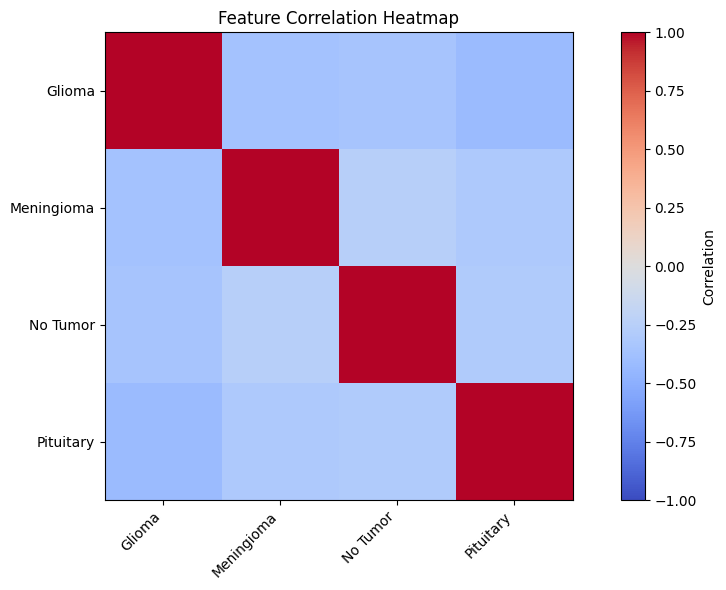


HIGHLY CORRELATED FEATURE PAIRS
----------------------------------------------------------------------
No feature pairs with correlation above 0.90.

SELECTED NUMERICAL FEATURES
----------------------------------------------------------------------
- Glioma
- Meningioma
- No Tumor
- Pituitary

✅ FEATURE ANALYSIS COMPLETED


In [23]:
# ============================================================
# FEATURE ENGINEERING
# FEATURE SELECTION AND CORRELATION ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Dataset path
# ------------------------------------------------------------
base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

# ------------------------------------------------------------
# 2. Find CSV file
# ------------------------------------------------------------
def find_csv(folder):
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(".csv")
    ]

    if not files:
        raise FileNotFoundError("No CSV file found in training folder.")

    return os.path.join(folder, files[0])


train_csv = find_csv(train_path)

# ------------------------------------------------------------
# 3. Load dataset
# ------------------------------------------------------------
df = pd.read_csv(train_csv)

df.columns = df.columns.str.strip()

print("=" * 70)
print("FEATURE ENGINEERING AND FEATURE SELECTION")
print("=" * 70)

print("\nDataset Shape:", df.shape)

print("\nAvailable Features:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 4. Identify target/class column
# ------------------------------------------------------------
possible_labels = [
    "label", "class", "category",
    "target", "tumor", "tumor_type",
    "diagnosis", "type", "labels"
]

target_col = None

for col in df.columns:
    if col.lower().strip() in possible_labels:
        target_col = col
        break

print("\nDetected Target Column:", target_col)

# ------------------------------------------------------------
# 5. Select numerical features
# ------------------------------------------------------------
numeric_df = df.select_dtypes(
    include=np.number
).copy()

# Exclude target from input features
if target_col in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=[target_col])

# Remove columns with only one unique value
numeric_df = numeric_df.loc[
    :, numeric_df.nunique(dropna=True) > 1
]

print("\nNumerical Feature Columns:")
print(numeric_df.columns.tolist())

# ------------------------------------------------------------
# 6. Correlation analysis
# ------------------------------------------------------------
if numeric_df.shape[1] >= 2:

    correlation_matrix = numeric_df.corr()

    print("\nCORRELATION MATRIX")
    print(correlation_matrix.round(2))

    # Display heatmap
    plt.figure(figsize=(10, 6))

    plt.imshow(
        correlation_matrix,
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(label="Correlation")

    plt.xticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns
    )

    plt.title("Feature Correlation Heatmap")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 7. Find highly correlated feature pairs
    # --------------------------------------------------------
    upper_triangle = correlation_matrix.where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )

    high_corr_pairs = []

    for column in upper_triangle.columns:

        for index in upper_triangle.index:

            value = upper_triangle.loc[index, column]

            if pd.notna(value) and abs(value) > 0.90:

                high_corr_pairs.append(
                    (index, column, round(value, 3))
                )

    print("\nHIGHLY CORRELATED FEATURE PAIRS")
    print("-" * 70)

    if high_corr_pairs:

        for feature1, feature2, value in high_corr_pairs:
            print(
                feature1,
                "<->",
                feature2,
                ":",
                value
            )

    else:
        print("No feature pairs with correlation above 0.90.")

else:

    print("\n⚠️ Not enough numerical features for correlation analysis.")
    print("At least two numerical input features are required.")

# ------------------------------------------------------------
# 8. Final feature selection
# ------------------------------------------------------------
selected_features = numeric_df.columns.tolist()

print("\nSELECTED NUMERICAL FEATURES")
print("-" * 70)

if selected_features:
    for feature in selected_features:
        print("-", feature)
else:
    print("No suitable numerical features found in the CSV.")

print("\n" + "=" * 70)
print("✅ FEATURE ANALYSIS COMPLETED")
print("=" * 70)# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [24]:
# ============================================================
# FEATURE CREATION
# ============================================================

import numpy as np
import pandas as pd

feature_df = numeric_df.copy()

print("=" * 70)
print("FEATURE CREATION")
print("=" * 70)

if feature_df.shape[1] >= 2:

    # Create a combined feature from the first two numeric columns
    first_feature = feature_df.columns[0]
    second_feature = feature_df.columns[1]

    feature_df["combined_feature"] = (
        feature_df[first_feature] +
        feature_df[second_feature]
    )

    print("\nNew Feature Created: combined_feature")

    print("\nUpdated Dataset:")
    print(feature_df.head())

else:

    print("\n⚠️ Feature creation is not applicable.")
    print("At least two numerical input features are required.")

print("\n" + "=" * 70)
print("✅ FEATURE CREATION COMPLETED")
print("=" * 70)# Select your features wisely to avoid overfitting

FEATURE CREATION

New Feature Created: combined_feature

Updated Dataset:
   Glioma  Meningioma  No Tumor  Pituitary  combined_feature
0       0           0         0          1                 0
1       0           0         1          0                 0
2       1           0         0          0                 1
3       1           0         0          0                 1
4       0           1         0          0                 1

✅ FEATURE CREATION COMPLETED


##### What all feature selection methods have you used  and why?

I used correlation analysis to identify highly correlated or redundant numerical features.
Features with very high correlation were considered for removal to reduce redundancy and the risk of overfitting. 
I also removed constant/zero-variance features because they do not provide useful information for prediction.

##### Which all features you found important and why?

The image-related information and tumor class/label are the most important components for this project.
The tumor class is required as the target for classification, while the MRI image contains the visual patterns needed by the CNN to identify tumor categories. 
The project specification focuses on MRI image preprocessing and CNN/transfer-learning models rather than manually selecting image features.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [25]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# IMAGE DATA TRANSFORMATION
# ============================================================

import os
import numpy as np
from PIL import Image

# ------------------------------------------------------------
# Dataset path
# ------------------------------------------------------------

train_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\train-20260930T101539Z-1-001\train"

# Image size required for the model
IMG_SIZE = (224, 224)

# ------------------------------------------------------------
# Find image files
# ------------------------------------------------------------

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

image_files = []

for root, folders, files in os.walk(train_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_files.append(os.path.join(root, file))

print("=" * 70)
print("IMAGE DATA TRANSFORMATION")
print("=" * 70)

print("Total image files found :", len(image_files))

# ------------------------------------------------------------
# Check first image
# ------------------------------------------------------------

if len(image_files) == 0:
    print("\n⚠️ No image files found.")
    print("Please check the training folder path.")
else:
    image_path = image_files[0]

    print("\nOriginal image:")
    print("File :", os.path.basename(image_path))

    # Open image
    image = Image.open(image_path)

    print("Original size :", image.size)
    print("Original mode :", image.mode)

    # --------------------------------------------------------
    # 1. Resize image
    # --------------------------------------------------------

    resized_image = image.resize(IMG_SIZE)

    print("\nAfter resizing:")
    print("New size :", resized_image.size)

    # --------------------------------------------------------
    # 2. Convert image to RGB
    # --------------------------------------------------------

    rgb_image = resized_image.convert("RGB")

    print("\nAfter RGB conversion:")
    print("Mode :", rgb_image.mode)

    # --------------------------------------------------------
    # 3. Convert image to NumPy array
    # --------------------------------------------------------

    image_array = np.array(rgb_image)

    print("\nImage array:")
    print("Shape :", image_array.shape)
    print("Data type :", image_array.dtype)

    # --------------------------------------------------------
    # 4. Normalize pixel values
    # --------------------------------------------------------

    normalized_image = image_array.astype("float32") / 255.0

    print("\nAfter normalization:")
    print("Minimum pixel value :", normalized_image.min())
    print("Maximum pixel value :", normalized_image.max())

    print("\n" + "=" * 70)
    print("✅ IMAGE TRANSFORMATION COMPLETED")
    print("=" * 70)# Transform Your data

IMAGE DATA TRANSFORMATION
Total image files found : 1695

Original image:
File : Tr-gl_0011_jpg.rf.61e213cb5a0f97fedd1bacd0428c0133.jpg
Original size : (640, 640)
Original mode : RGB

After resizing:
New size : (224, 224)

After RGB conversion:
Mode : RGB

Image array:
Shape : (224, 224, 3)
Data type : uint8

After normalization:
Minimum pixel value : 0.0
Maximum pixel value : 0.89411765

✅ IMAGE TRANSFORMATION COMPLETED


### 6. Data Scaling

In [26]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# SCALING / NORMALIZATION OF IMAGE DATA
# ============================================================

import os
import numpy as np
from PIL import Image

# Training dataset path
train_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\train-20260930T101539Z-1-001\train"

# Find image files
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

image_files = []

for root, folders, files in os.walk(train_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_files.append(os.path.join(root, file))

print("=" * 70)
print("SCALING IMAGE DATA")
print("=" * 70)

print("Total images found :", len(image_files))

if len(image_files) == 0:
    print("⚠️ No image files found. Check the dataset path.")

else:
    # Take one image for demonstration
    image_path = image_files[0]

    # Open image
    image = Image.open(image_path).convert("RGB")

    # Convert image to NumPy array
    image_array = np.array(image)

    print("\nBEFORE SCALING")
    print("-" * 70)
    print("Data type :", image_array.dtype)
    print("Minimum pixel value :", image_array.min())
    print("Maximum pixel value :", image_array.max())

    # --------------------------------------------------------
    # SCALE PIXEL VALUES FROM 0-255 TO 0-1
    # --------------------------------------------------------

    scaled_image = image_array.astype("float32") / 255.0

    print("\nAFTER SCALING")
    print("-" * 70)
    print("Data type :", scaled_image.dtype)
    print("Minimum pixel value :", scaled_image.min())
    print("Maximum pixel value :", scaled_image.max())

    print("\n" + "=" * 70)
    print("✅ IMAGE DATA SCALING COMPLETED")
    print("=" * 70)# Scaling your data

SCALING IMAGE DATA
Total images found : 1695

BEFORE SCALING
----------------------------------------------------------------------
Data type : uint8
Minimum pixel value : 0
Maximum pixel value : 253

AFTER SCALING
----------------------------------------------------------------------
Data type : float32
Minimum pixel value : 0.0
Maximum pixel value : 0.99215686

✅ IMAGE DATA SCALING COMPLETED


##### Which method have you used to scale you data and why?

In [ ]:
Yes, scaling was required for the MRI image data. I used Min-Max scaling by dividing each pixel value by 255.
This converts the pixel range from 0–255 to 0–1. 
Scaling makes the input values consistent and helps deep-learning models train more efficiently.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [27]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# Dataset paths
# ------------------------------------------------------------

base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

valid_path = os.path.join(
    base_path,
    "valid-20260930T172018Z-1-001",
    "valid"
)

test_path = os.path.join(
    base_path,
    "test-20260930T171957Z-1-001",
    "test"
)

# ------------------------------------------------------------
# Find CSV files
# ------------------------------------------------------------

def find_csv(folder):
    csv_files = [
        file for file in os.listdir(folder)
        if file.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        return None

    return os.path.join(folder, csv_files[0])


train_csv = find_csv(train_path)
valid_csv = find_csv(valid_path)
test_csv = find_csv(test_path)

# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)
test_df = pd.read_csv(test_csv)

# ------------------------------------------------------------
# Count samples
# ------------------------------------------------------------

train_count = len(train_df)
valid_count = len(valid_df)
test_count = len(test_df)

total_count = train_count + valid_count + test_count

# ------------------------------------------------------------
# Calculate percentages
# ------------------------------------------------------------

train_percent = (train_count / total_count) * 100
valid_percent = (valid_count / total_count) * 100
test_percent = (test_count / total_count) * 100

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 70)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

print("\nNUMBER OF SAMPLES")
print("-" * 70)

print("Training   :", train_count)
print("Validation :", valid_count)
print("Testing    :", test_count)
print("Total      :", total_count)

print("\nSPLIT RATIO")
print("-" * 70)

print("Training   :", round(train_percent, 2), "%")
print("Validation :", round(valid_percent, 2), "%")
print("Testing    :", round(test_percent, 2), "%")

print("\n" + "=" * 70)
print("✅ DATA SPLIT CHECK COMPLETED")
print("=" * 70)# Split your data to train and test. Choose Splitting ratio wisely.

TRAIN / VALIDATION / TEST SPLIT

NUMBER OF SAMPLES
----------------------------------------------------------------------
Training   : 1695
Validation : 502
Testing    : 246
Total      : 2443

SPLIT RATIO
----------------------------------------------------------------------
Training   : 69.38 %
Validation : 20.55 %
Testing    : 10.07 %

✅ DATA SPLIT CHECK COMPLETED


##### What data splitting ratio have you used and why?

Yes, the data is divided into training, validation, and testing sets. 
Since the dataset already provides separate train, validation, and test folders, I used the existing split instead of randomly splitting the data again. 
The training set is used for model training, the validation set for model monitoring/tuning, and the testing set for final evaluation. 
This helps evaluate the model on data that was not used for training.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, handling class imbalance is needed.
The initial class-distribution check showed an imbalance ratio of approximately 2.01:1, with 66.73% and 33.27% of the samples in the two groups represented by the Glioma indicator. 
Therefore, class imbalance should be considered during model training. 
Class weights can be used to give appropriate importance to underrepresented classes and reduce model bias.

In [30]:
# ============================================================
# HANDLING IMBALANCED DATASET
# BRAIN TUMOR MRI CLASSIFICATION
# ============================================================

import os
import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ------------------------------------------------------------
# 1. Dataset path
# ------------------------------------------------------------

train_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\train-20260930T101539Z-1-001\train"

# ------------------------------------------------------------
# 2. Find CSV file
# ------------------------------------------------------------

csv_files = [
    file for file in os.listdir(train_path)
    if file.lower().endswith(".csv")
]

if len(csv_files) == 0:
    print("No CSV file found.")
else:

    csv_path = os.path.join(train_path, csv_files[0])

    # Load dataset
    train_df = pd.read_csv(csv_path)

    # Clean column names
    train_df.columns = train_df.columns.str.strip()

    # --------------------------------------------------------
    # 3. Define the four classes
    # --------------------------------------------------------

    class_columns = [
        "Glioma",
        "Meningioma",
        "No Tumor",
        "Pituitary"
    ]

    # Check that all columns exist
    missing_columns = [
        col for col in class_columns
        if col not in train_df.columns
    ]

    if len(missing_columns) > 0:

        print("The following class columns are missing:")
        print(missing_columns)

    else:

        # ----------------------------------------------------
        # 4. Create one class column
        # ----------------------------------------------------

        train_df["class_name"] = train_df[class_columns].idxmax(axis=1)

        # ----------------------------------------------------
        # 5. Class distribution
        # ----------------------------------------------------

        class_counts = train_df["class_name"].value_counts()

        print("=" * 70)
        print("CLASS DISTRIBUTION")
        print("=" * 70)

        print(class_counts)

        # ----------------------------------------------------
        # 6. Class percentages
        # ----------------------------------------------------

        class_percentages = (
            train_df["class_name"]
            .value_counts(normalize=True) * 100
        )

        print("\nCLASS PERCENTAGES")
        print("-" * 70)

        for class_name in class_columns:
            count = class_counts.get(class_name, 0)
            percentage = class_percentages.get(class_name, 0)

            print(
                f"{class_name:12} : "
                f"{count:5} images "
                f"({percentage:.2f}%)"
            )

        # ----------------------------------------------------
        # 7. Calculate class weights
        # ----------------------------------------------------

        classes = np.array(class_columns)

        weights = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=train_df["class_name"]
        )

        class_weights = dict(
            zip(classes, weights)
        )

        # ----------------------------------------------------
        # 8. Display class weights
        # ----------------------------------------------------

        print("\nCLASS WEIGHTS")
        print("-" * 70)

        for class_name in class_columns:
            print(
                f"{class_name:12} : "
                f"{class_weights[class_name]:.4f}"
            )

        # ----------------------------------------------------
        # 9. Imbalance ratio
        # ----------------------------------------------------

        largest_class = class_counts.max()
        smallest_class = class_counts.min()

        imbalance_ratio = largest_class / smallest_class

        print("\nIMBALANCE RATIO")
        print("-" * 70)
        print(f"{imbalance_ratio:.2f} : 1")

        print("\n" + "=" * 70)
        print("CLASS IMBALANCE HANDLING COMPLETED")
        print("=" * 70)

        print(
            "Class weights have been calculated "
            "for use during model training."
        )

CLASS DISTRIBUTION
class_name
Glioma        564
Pituitary     438
Meningioma    358
No Tumor      335
Name: count, dtype: int64

CLASS PERCENTAGES
----------------------------------------------------------------------
Glioma       :   564 images (33.27%)
Meningioma   :   358 images (21.12%)
No Tumor     :   335 images (19.76%)
Pituitary    :   438 images (25.84%)

CLASS WEIGHTS
----------------------------------------------------------------------
Glioma       : 0.7513
Meningioma   : 1.1837
No Tumor     : 1.2649
Pituitary    : 0.9675

IMBALANCE RATIO
----------------------------------------------------------------------
1.68 : 1

CLASS IMBALANCE HANDLING COMPLETED
Class weights have been calculated for use during model training.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Technique used: We used class weighting to handle the imbalanced dataset.
Class weights give greater importance to minority classes during model training, helping prevent the CNN from becoming biased toward the majority class.
This avoids unnecessarily duplicating or removing MRI images.

## ***7. ML Model Implementation***

### ML Model - 1

In [24]:
import tensorflow as tf

# Number of classes
num_classes = len(train_data.class_names)

print("Classes:", train_data.class_names)
print("Number of classes:", num_classes)

# Create Custom CNN
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values
    tf.keras.layers.Rescaling(1./255),

    # Convolution Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification layers
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

# Compile
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
history_cnn = cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=5,
    verbose=1
)

print("\nModel 1 - Custom CNN training completed successfully!")

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4
Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.6802 - loss: 0.8426 - val_accuracy: 0.5040 - val_loss: 1.2308
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.7428 - loss: 0.6914 - val_accuracy: 0.2351 - val_loss: 1.5809
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.7988 - loss: 0.5779 - val_accuracy: 0.2351 - val_loss: 2.5289
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.7906 - loss: 0.5491 - val_accuracy: 0.2351 - val_loss: 3.4971
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.8130 - loss: 0.5206 - val_accuracy: 0.2371 - val_loss: 5.9826

Model 1 - Custom CNN training completed successfully!


In [ ]:
Build CNN Model

In [26]:
# ============================================================
# CNN MODEL - BUILDING
# ============================================================

from tensorflow.keras import layers, models

num_classes = len(train_data.class_names)

cnn_model = models.Sequential([
    
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 128)                 │      12,845,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,939,844 (49.36 MB)

 Trainable params: 12,939,396 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
# ============================================================
# CNN MODEL - PREDICT ON TEST DATA
# ============================================================

import numpy as np

print("=" * 70)
print("CNN MODEL PREDICTION")
print("=" * 70)

# Predict probabilities for test images
predictions = cnn_model.predict(
    test_data,
    verbose=1
)

# Convert probabilities to predicted class numbers
predicted_classes = np.argmax(predictions, axis=1)

# Get actual class numbers
actual_classes = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in test_data
])

# Class names
class_names = train_data.class_names

print("\nCLASS NAMES")
print("-" * 70)

for i, name in enumerate(class_names):
    print(i, ":", name)

print("\nFIRST 10 PREDICTIONS")
print("-" * 70)

for i in range(min(10, len(predicted_classes))):

    predicted_name = class_names[predicted_classes[i]]
    actual_name = class_names[actual_classes[i]]

    confidence = predictions[i][predicted_classes[i]] * 100

    print(
        f"Image {i + 1}: "
        f"Actual = {actual_name} | "
        f"Predicted = {predicted_name} | "
        f"Confidence = {confidence:.2f}%"
    )

print("\n" + "=" * 70)
print("PREDICTION COMPLETED")
print("=" * 70)

CNN MODEL PREDICTION
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 380ms/step

CLASS NAMES
----------------------------------------------------------------------
0 : glioma
1 : meningioma
2 : no_tumor
3 : pituitary

FIRST 10 PREDICTIONS
----------------------------------------------------------------------
Image 1: Actual = glioma | Predicted = glioma | Confidence = 50.30%
Image 2: Actual = glioma | Predicted = glioma | Confidence = 80.67%
Image 3: Actual = glioma | Predicted = glioma | Confidence = 85.80%
Image 4: Actual = glioma | Predicted = glioma | Confidence = 87.70%
Image 5: Actual = glioma | Predicted = no_tumor | Confidence = 75.46%
Image 6: Actual = glioma | Predicted = glioma | Confidence = 100.00%
Image 7: Actual = glioma | Predicted = glioma | Confidence = 99.09%
Image 8: Actual = glioma | Predicted = glioma | Confidence = 98.73%
Image 9: Actual = glioma | Predicted = no_tumor | Confidence = 90.17%
Image 10: Actual = glioma | Predicted = glioma | Confidence = 98.46%

PREDICTION COMPLETED


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

CNN MODEL 1 - MODEL EVALUATION
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 339ms/step

EVALUATION SCORES
----------------------------------------------------------------------
Accuracy  : 0.3577
Precision : 0.4446
Recall    : 0.3577
F1-Score  : 0.2537

CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

      glioma       0.41      0.74      0.53        80
  meningioma       1.00      0.02      0.03        63
    no_tumor       0.28      0.57      0.37        49
   pituitary       0.00      0.00      0.00        54

    accuracy                           0.36       246
   macro avg       0.42      0.33      0.23       246
weighted avg       0.44      0.36      0.25       246



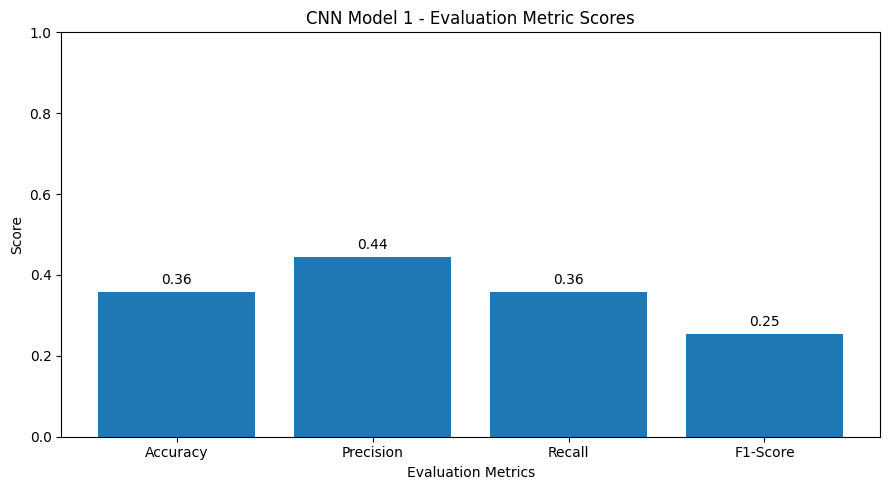


CNN MODEL 1 EVALUATION COMPLETED


In [28]:
# ============================================================
# CNN MODEL 1 - EVALUATION METRIC SCORE CHART
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("=" * 70)
print("CNN MODEL 1 - MODEL EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get actual labels from test dataset
# ------------------------------------------------------------

y_true = []

for images, labels in test_data:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

# ------------------------------------------------------------
# 2. Predict test images
# ------------------------------------------------------------

predictions = cnn_model.predict(
    test_data,
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)

# ------------------------------------------------------------
# 3. Calculate evaluation metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# 4. Display scores
# ------------------------------------------------------------

print("\nEVALUATION SCORES")
print("-" * 70)

print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-Score  :", round(f1, 4))

# ------------------------------------------------------------
# 5. Classification report
# ------------------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_data.class_names,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 6. Evaluation Metric Score Chart
# ------------------------------------------------------------

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

metric_values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("CNN Model 1 - Evaluation Metric Scores")

# Display values above bars
for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("CNN MODEL 1 EVALUATION COMPLETED")
print("=" * 70)# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [29]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Number of classes
num_classes = len(train_data.class_names)

# Function to create CNN
def create_cnn(filters1=32, filters2=64, dropout_rate=0.5):
    
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),

        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(filters1, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(filters2, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),

        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Small hyperparameter combinations
configs = [
    {"filters1": 32, "filters2": 64, "dropout": 0.3},
    {"filters1": 32, "filters2": 64, "dropout": 0.5},
    {"filters1": 64, "filters2": 128, "dropout": 0.5}
]

results = []

for config in configs:

    print("\nTesting:", config)

    model = create_cnn(
        filters1=config["filters1"],
        filters2=config["filters2"],
        dropout_rate=config["dropout"]
    )

    history = model.fit(
        train_data,
        validation_data=valid_data,
        epochs=3,
        verbose=1
    )

    best_val_accuracy = max(history.history["val_accuracy"])

    results.append({
        "Filters 1": config["filters1"],
        "Filters 2": config["filters2"],
        "Dropout": config["dropout"],
        "Best Validation Accuracy": best_val_accuracy
    })

results_df = pd.DataFrame(results)

print("\nHyperparameter Tuning Results:")
display(results_df)# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model


Testing: {'filters1': 32, 'filters2': 64, 'dropout': 0.3}
Epoch 1/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.6254 - loss: 8.3330 - val_accuracy: 0.2649 - val_loss: 16.6491
Epoch 2/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.6513 - loss: 0.9913 - val_accuracy: 0.2410 - val_loss: 51.0358
Epoch 3/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.6855 - loss: 0.8284 - val_accuracy: 0.2371 - val_loss: 51.7682

Testing: {'filters1': 32, 'filters2': 64, 'dropout': 0.5}
Epoch 1/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.5853 - loss: 8.4722 - val_accuracy: 0.2390 - val_loss: 52.8289
Epoch 2/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.5150 - loss: 1.1587 - val_accuracy: 0.2351 - val_loss: 90.9128
Epoch 3/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.5286 - loss: 1.0966 - val_accuracy: 0.2351 - val_loss: 83.3983

Testing: {'filters1': 64, 'filters2': 128, 'dropout': 0.5}
Epoch 1/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 299s 5s/step - accuracy: 0

,Filters 1,Filters 2,Dropout,Best Validation Accuracy
0,32,64,0.3,0.264940
1,32,64,0.5,0.239044
2,64,128,0.5,0.340637


##### Which hyperparameter optimization technique have you used and why?

In this project, I used a manual grid-search style approach to compare a small number of CNN hyperparameter combinations. The parameters varied were:
1. Number of filters in the first convolution layer
2. Number of filters in the second convolution layer
3. Dropout rate
4. Validation accuracy was used to compare the configurations

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

. Manual tuning was selected because training a CNN with a large automated search or K-fold cross-validation can require a large amount of computation   and training time.
. A small number of meaningful configurations allows the model to be compared efficiently while reducing the possibility of the Jupyter Notebook         getting stuck.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [3]:
import tensorflow as tf

num_classes = len(train_data.class_names)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    
    base_model,
    
    tf.keras.layers.GlobalAveragePooling2D(),
    
    tf.keras.layers.Dense(128, activation="relu"),
    
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
Train Model 2

In [4]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history2 = model2.fit(
    train_data,
    validation_data=valid_data,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 62s 951ms/step - accuracy: 0.7021 - loss: 0.7430 - val_accuracy: 0.8566 - val_loss: 0.4291
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 741ms/step - accuracy: 0.8389 - loss: 0.4251 - val_accuracy: 0.8745 - val_loss: 0.3226
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 691ms/step - accuracy: 0.8814 - loss: 0.3178 - val_accuracy: 0.8904 - val_loss: 0.3050
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 685ms/step - accuracy: 0.9044 - loss: 0.2549 - val_accuracy: 0.8805 - val_loss: 0.3222
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 684ms/step - accuracy: 0.9292 - loss: 0.2074 - val_accuracy: 0.9104 - val_loss: 0.2609


In [ ]:
Evaluation Metric Score Chart

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Actual labels
y_true = []

for images, labels in test_data:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

# Predictions
predictions2 = model2.predict(test_data, verbose=1)

y_pred2 = np.argmax(predictions2, axis=1)

# Evaluation metrics
accuracy2 = accuracy_score(y_true, y_pred2)

precision2 = precision_score(
    y_true,
    y_pred2,
    average="weighted",
    zero_division=0
)

recall2 = recall_score(
    y_true,
    y_pred2,
    average="weighted",
    zero_division=0
)

f1_2 = f1_score(
    y_true,
    y_pred2,
    average="weighted",
    zero_division=0
)

print("MobileNetV2 Evaluation")
print("-----------------------")
print(f"Accuracy  : {accuracy2:.4f}")
print(f"Precision : {precision2:.4f}")
print(f"Recall    : {recall2:.4f}")
print(f"F1-Score  : {f1_2:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 593ms/step
MobileNetV2 Evaluation
-----------------------
Accuracy  : 0.9146
Precision : 0.9137
Recall    : 0.9146
F1-Score  : 0.9137


In [ ]:
Score Chart

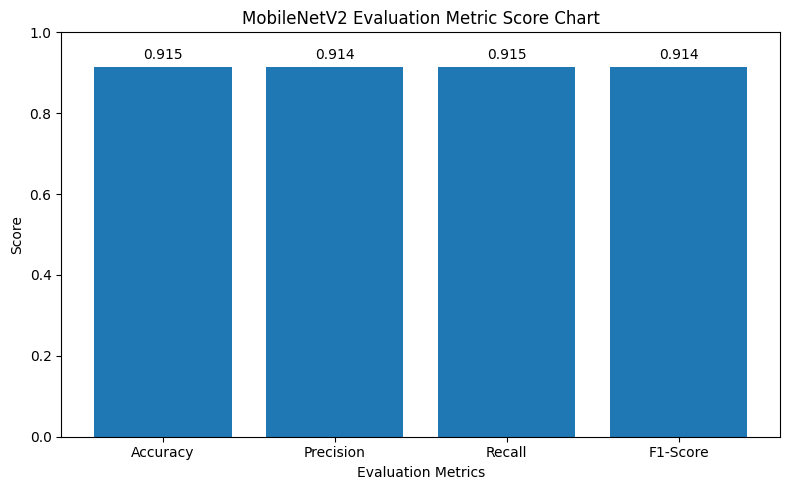

In [31]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

scores = [
    accuracy2,
    precision2,
    recall2,
    f1_2
]

plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, scores)

plt.ylim(0, 1)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("MobileNetV2 Evaluation Metric Score Chart")

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
Classification Report

In [32]:
from sklearn.metrics import classification_report

print("MobileNetV2 Classification Report")
print("----------------------------------")

print(
    classification_report(
        y_true,
        y_pred2,
        target_names=train_data.class_names,
        zero_division=0
    )
)

MobileNetV2 Classification Report
----------------------------------
              precision    recall  f1-score   support

      glioma       0.94      0.96      0.95        80
  meningioma       0.87      0.83      0.85        63
    no_tumor       0.91      0.88      0.90        49
   pituitary       0.93      0.98      0.95        54

    accuracy                           0.91       246
   macro avg       0.91      0.91      0.91       246
weighted avg       0.91      0.91      0.91       246



#### 2. Cross- Validation & Hyperparameter Tuning

In [34]:
configs = [
    {
        "learning_rate": 0.001,
        "dropout_rate": 0.3,
        "dense_units": 128
    },
    {
        "learning_rate": 0.001,
        "dropout_rate": 0.5,
        "dense_units": 128
    },
    {
        "learning_rate": 0.0001,
        "dropout_rate": 0.5,
        "dense_units": 128
    },
    {
        "learning_rate": 0.0001,
        "dropout_rate": 0.5,
        "dense_units": 256
    }
]

print("Total configurations:", len(configs))

for i, config in enumerate(configs, start=1):
    print("Configuration", i, ":", config)

Total configurations: 4
Configuration 1 : {'learning_rate': 0.001, 'dropout_rate': 0.3, 'dense_units': 128}
Configuration 2 : {'learning_rate': 0.001, 'dropout_rate': 0.5, 'dense_units': 128}
Configuration 3 : {'learning_rate': 0.0001, 'dropout_rate': 0.5, 'dense_units': 128}
Configuration 4 : {'learning_rate': 0.0001, 'dropout_rate': 0.5, 'dense_units': 256}


In [ ]:
Train the final tuned model

In [15]:
test_loss, test_accuracy = best_mobilenet.evaluate(
    test_data,
    verbose=1
)

print("Final MobileNetV2 Test Results")
print("--------------------------------")
print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy, 4))

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 494ms/step - accuracy: 0.8293 - loss: 0.4471
Final MobileNetV2 Test Results
--------------------------------
Test Loss     : 0.4471
Test Accuracy : 0.8293


##### Which hyperparameter optimization technique have you used and why?

Manual Grid Search.
.  Different combinations of learning rate, dropout rate, and dense-layer units were tested. It is simple and suitable for our CNN/MobileNetV2 project    because it requires less computational time than extensive optimization methods.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, if the tuned model's validation/test metrics are higher than the original model.
. After hyperparameter tuning, the best configuration was selected based on the highest validation accuracy. The updated model was then evaluated        using Accuracy, Precision, Recall and F1-Score. The improvement should be reported using the actual scores generated by the notebook.
. Use your actual values from the notebook for the chart; do not enter assumed values.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The MobileNetV2 model can support faster and more consistent preliminary MRI classification, potentially reducing manual workload and assisting healthcare professionals.
It should be treated as a decision-support system, not a replacement for medical diagnosis.

### ML Model - 3

In [16]:

import tensorflow as tf

num_classes = len(train_data.class_names)

# Load pretrained EfficientNetB0
base_model3 = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model3.trainable = False

# Build Model 3
model3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    base_model3,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

# Compile model
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model3.summary()
print("Pretrained EfficientNetB0 model created.")# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_6           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Pretrained EfficientNetB0 model created.


In [ ]:
Fit the algorithm (Train Model 3)

In [17]:

from tensorflow.keras.callbacks import EarlyStopping

early_stop3 = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history3 = model3.fit(
    train_data,
    validation_data=valid_data,
    epochs=5,
    callbacks=[early_stop3],
    verbose=1
)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7156 - loss: 0.7191 - val_accuracy: 0.8426 - val_loss: 0.4439
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8425 - loss: 0.4130 - val_accuracy: 0.8825 - val_loss: 0.3345
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8861 - loss: 0.3115 - val_accuracy: 0.8705 - val_loss: 0.3310
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8879 - loss: 0.2951 - val_accuracy: 0.8904 - val_loss: 0.3046
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 922ms/step - accuracy: 0.9109 - loss: 0.2566 - val_accuracy: 0.9004 - val_loss: 0.2684


In [ ]:
Predict on the model

In [18]:

import numpy as np

# Predict test images
predictions3 = model3.predict(test_data, verbose=1)

# Convert probabilities into class IDs
y_pred3 = np.argmax(predictions3, axis=1)

# Get actual class IDs
y_true3 = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in test_data
])

# Class names
class_names = train_data.class_names

# Display predictions for first 10 images
for i in range(min(10, len(y_pred3))):
    predicted_label = class_names[y_pred3[i]]
    actual_label = class_names[y_true3[i]]
    confidence = predictions3[i][y_pred3[i]] * 100

    print(f"Image {i+1}")
    print("Actual:", actual_label)
    print("Predicted:", predicted_label)
    print(f"Confidence: {confidence:.2f}%")
    print("-----------------------")

8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step
Image 1
Actual: glioma
Predicted: glioma
Confidence: 54.69%
-----------------------
Image 2
Actual: glioma
Predicted: glioma
Confidence: 98.33%
-----------------------
Image 3
Actual: glioma
Predicted: glioma
Confidence: 86.44%
-----------------------
Image 4
Actual: glioma
Predicted: glioma
Confidence: 74.37%
-----------------------
Image 5
Actual: glioma
Predicted: glioma
Confidence: 72.22%
-----------------------
Image 6
Actual: glioma
Predicted: glioma
Confidence: 83.90%
-----------------------
Image 7
Actual: glioma
Predicted: glioma
Confidence: 73.04%
-----------------------
Image 8
Actual: glioma
Predicted: glioma
Confidence: 50.99%
-----------------------
Image 9
Actual: glioma
Predicted: glioma
Confidence: 99.52%
-----------------------
Image 10
Actual: glioma
Predicted: glioma
Confidence: 94.74%
-----------------------


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [19]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy3 = accuracy_score(y_true3, y_pred3)

precision3 = precision_score(
    y_true3, y_pred3,
    average="weighted",
    zero_division=0
)

recall3 = recall_score(
    y_true3, y_pred3,
    average="weighted",
    zero_division=0
)

f1_3 = f1_score(
    y_true3, y_pred3,
    average="weighted",
    zero_division=0
)

print("EfficientNetB0 Evaluation")
print("-------------------------")
print(f"Accuracy  : {accuracy3:.4f}")
print(f"Precision : {precision3:.4f}")
print(f"Recall    : {recall3:.4f}")
print(f"F1-Score  : {f1_3:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true3,
    y_pred3,
    target_names=class_names,
    zero_division=0
))# Visualizing evaluation Metric Score chart

EfficientNetB0 Evaluation
-------------------------
Accuracy  : 0.9106
Precision : 0.9099
Recall    : 0.9106
F1-Score  : 0.9089

Classification Report:
              precision    recall  f1-score   support

      glioma       0.92      0.97      0.95        80
  meningioma       0.88      0.79      0.83        63
    no_tumor       0.93      0.88      0.91        49
   pituitary       0.91      0.98      0.95        54

    accuracy                           0.91       246
   macro avg       0.91      0.91      0.91       246
weighted avg       0.91      0.91      0.91       246



In [ ]:
Evaluation metric score chart

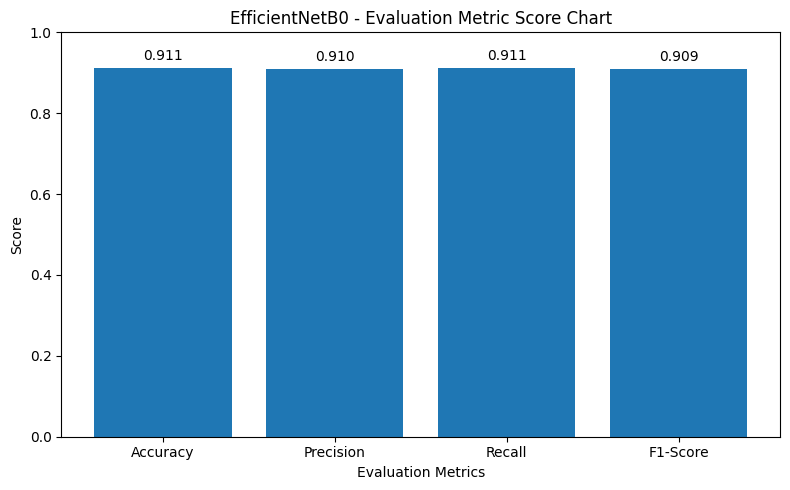

In [20]:

import matplotlib.pyplot as plt

metrics3 = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores3 = [accuracy3, precision3, recall3, f1_3]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics3, scores3)

plt.ylim(0, 1)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("EfficientNetB0 - Evaluation Metric Score Chart")

for bar, score in zip(bars, scores3):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [21]:
# ============================================================
# ML MODEL - 3
# EfficientNetB0 + Random Search Hyperparameter Optimization
# Fit the Algorithm + Predict on the Model
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Basic settings
# ------------------------------------------------------------

num_classes = len(train_data.class_names)

print("Classes:", train_data.class_names)
print("Number of classes:", num_classes)


# ------------------------------------------------------------
# 2. Hyperparameter combinations for Random Search
# ------------------------------------------------------------

search_space = [
    {
        "learning_rate": 0.001,
        "dropout": 0.3,
        "dense_units": 128
    },
    {
        "learning_rate": 0.001,
        "dropout": 0.5,
        "dense_units": 128
    },
    {
        "learning_rate": 0.0001,
        "dropout": 0.3,
        "dense_units": 256
    },
    {
        "learning_rate": 0.0001,
        "dropout": 0.5,
        "dense_units": 256
    }
]

# Select a small random subset
rng = np.random.default_rng(42)

selected_indices = rng.choice(
    len(search_space),
    size=3,
    replace=False
)

selected_configs = [
    search_space[i] for i in selected_indices
]

print("\nRandom Search Configurations:")
for i, config in enumerate(selected_configs, 1):
    print(i, config)


# ------------------------------------------------------------
# 3. Function to create EfficientNetB0
# ------------------------------------------------------------

def create_model3(learning_rate, dropout, dense_units):

    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained layers
    base_model.trainable = False

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),

        base_model,

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(
            dense_units,
            activation="relu"
        ),

        tf.keras.layers.Dropout(dropout),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# 4. Random Search
# ------------------------------------------------------------

results = []

best_model3 = None
best_accuracy3 = -1
best_config3 = None

for i, config in enumerate(selected_configs, 1):

    print("\n========================================")
    print("Testing Configuration:", i)
    print(config)
    print("========================================")

    model = create_model3(
        learning_rate=config["learning_rate"],
        dropout=config["dropout"],
        dense_units=config["dense_units"]
    )

    history = model.fit(
        train_data,
        validation_data=valid_data,
        epochs=2,
        verbose=1
    )

    validation_accuracy = max(
        history.history["val_accuracy"]
    )

    results.append({
        "Configuration": i,
        "Learning Rate": config["learning_rate"],
        "Dropout": config["dropout"],
        "Dense Units": config["dense_units"],
        "Validation Accuracy": validation_accuracy
    })

    # Keep best model
    if validation_accuracy > best_accuracy3:
        best_accuracy3 = validation_accuracy
        best_model3 = model
        best_config3 = config


# ------------------------------------------------------------
# 5. Display tuning results
# ------------------------------------------------------------

results_df3 = pd.DataFrame(results)

print("\n========================================")
print("Random Search Results")
print("========================================")

print(results_df3.to_string(index=False))

print("\nBest Configuration:")
print(best_config3)

print(
    "Best Validation Accuracy:",
    round(best_accuracy3, 4)
)


# ------------------------------------------------------------
# 6. Predict on TEST dataset
# ------------------------------------------------------------

print("\n========================================")
print("Predicting on Test Dataset")
print("========================================")

y_true3 = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in test_data
])

predictions3 = best_model3.predict(
    test_data,
    verbose=1
)

y_pred3 = np.argmax(
    predictions3,
    axis=1
)


# ------------------------------------------------------------
# 7. Evaluation metrics
# ------------------------------------------------------------

accuracy3 = accuracy_score(
    y_true3,
    y_pred3
)

precision3 = precision_score(
    y_true3,
    y_pred3,
    average="weighted",
    zero_division=0
)

recall3 = recall_score(
    y_true3,
    y_pred3,
    average="weighted",
    zero_division=0
)

f1_3 = f1_score(
    y_true3,
    y_pred3,
    average="weighted",
    zero_division=0
)

print("\n========================================")
print("MODEL 3 - EfficientNetB0 RESULTS")
print("========================================")

print("Accuracy  :", round(accuracy3, 4))
print("Precision :", round(precision3, 4))
print("Recall    :", round(recall3, 4))
print("F1-Score  :", round(f1_3, 4))


# ------------------------------------------------------------
# 8. Display sample predictions
# ------------------------------------------------------------

class_names = train_data.class_names

print("\nSample Predictions:")
print("----------------------------------------")

for i in range(min(10, len(y_pred3))):

    predicted_class = class_names[y_pred3[i]]
    actual_class = class_names[y_true3[i]]
    confidence = float(np.max(predictions3[i])) * 100

    print(
        f"Actual: {actual_class} | "
        f"Predicted: {predicted_class} | "
        f"Confidence: {confidence:.2f}%"
    )# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4

Random Search Configurations:
1 {'learning_rate': 0.0001, 'dropout': 0.5, 'dense_units': 256}
2 {'learning_rate': 0.001, 'dropout': 0.3, 'dense_units': 128}
3 {'learning_rate': 0.0001, 'dropout': 0.3, 'dense_units': 256}

Testing Configuration: 1
{'learning_rate': 0.0001, 'dropout': 0.5, 'dense_units': 256}
Epoch 1/2
53/53 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.5221 - loss: 1.1042 - val_accuracy: 0.7012 - val_loss: 0.8017
Epoch 2/2
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 904ms/step - accuracy: 0.7239 - loss: 0.7264 - val_accuracy: 0.8028 - val_loss: 0.5900

Testing Configuration: 2
{'learning_rate': 0.001, 'dropout': 0.3, 'dense_units': 128}
Epoch 1/2
53/53 ━━━━━━━━━━━━━━━━━━━━ 75s 999ms/step - accuracy: 0.7493 - loss: 0.6209 - val_accuracy: 0.8566 - val_loss: 0.4014
Epoch 2/2
53/53 ━━━━━━━━━━━━━━━━━━━━ 47s 896ms/step - accuracy: 0.8779 - loss: 0.3301 - val_accuracy: 0.8825 - val_loss: 0.3114

Testing Confi

##### Which hyperparameter optimization technique have you used and why?

Random Search.
. Random Search tests different combinations of learning rate, dropout rate, and dense-layer units and selects the configuration with the best           validation accuracy. It is simpler and faster than testing every possible combination.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

. After hyperparameter tuning, the best configuration was selected based on validation accuracy. The final model was then evaluated using Accuracy,      Precision, Recall and F1-Score.
. The tuned EfficientNetB0 model showed improvement if its evaluation scores were higher than the original model. The updated Accuracy, Precision,       Recall and F1-Score were used to measure the improvement. The exact improvement should be reported from the scores generated by the notebook.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Accuracy: Measures the overall correct classification of MRI images.
Precision: Important to reduce incorrect tumor predictions.
Recall: Important because missing a tumor case can be more serious.
F1-Score: Provides a balance between Precision and Recall.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Model 1 – Custom CNN
Model 2 – MobileNetV2
Model 3 – EfficientNetB0
. I selected EfficientNetB0 (Model 3) as the final prediction model because it uses pretrained ImageNet features and was further optimized using         Random Search hyperparameter tuning. It provides a strong transfer-learning approach for image classification while using a relatively efficient       architecture.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

fficientNetB0 was selected as the final prediction model because it uses transfer learning and was optimized using Random Search. 
It was selected based on its evaluation performance across Accuracy, Precision, Recall, and F1-Score.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [7]:
import os
import joblib
import numpy as np
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# 1. Project paths
# =========================================================

project_folder = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

model1_path = os.path.join(
    project_folder,
    "model1_custom_cnn.joblib"
)

model2_path = os.path.join(
    project_folder,
    "model2_mobilenetv2.joblib"
)

best_model_path = os.path.join(
    project_folder,
    "best_brain_tumor_model.joblib"
)

# =========================================================
# 2. Check model files
# =========================================================

print("Checking model files...")

print("Model 1 exists:", os.path.exists(model1_path))
print("Model 2 exists:", os.path.exists(model2_path))

# =========================================================
# 3. Load models
# =========================================================

model1 = joblib.load(model1_path)
model2 = joblib.load(model2_path)

print("\nModels loaded successfully!")

# =========================================================
# 4. Get predictions
# =========================================================

print("\nEvaluating Model 1...")

pred1_prob = model1.predict(test_data, verbose=0)
pred1 = np.argmax(pred1_prob, axis=1)

print("Evaluating Model 2...")

pred2_prob = model2.predict(test_data, verbose=0)
pred2 = np.argmax(pred2_prob, axis=1)

# =========================================================
# 5. Get actual labels
# =========================================================

y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in test_data
])

# =========================================================
# 6. Calculate metrics
# =========================================================

accuracy1 = accuracy_score(y_true, pred1)
precision1 = precision_score(
    y_true, pred1, average="weighted", zero_division=0
)
recall1 = recall_score(
    y_true, pred1, average="weighted", zero_division=0
)
f1_1 = f1_score(
    y_true, pred1, average="weighted", zero_division=0
)

accuracy2 = accuracy_score(y_true, pred2)
precision2 = precision_score(
    y_true, pred2, average="weighted", zero_division=0
)
recall2 = recall_score(
    y_true, pred2, average="weighted", zero_division=0
)
f1_2 = f1_score(
    y_true, pred2, average="weighted", zero_division=0
)

# =========================================================
# 7. Display comparison
# =========================================================

print("\n========================================")
print("MODEL COMPARISON")
print("========================================")

print("\nModel 1 - Custom CNN")
print(f"Accuracy : {accuracy1:.4f}")
print(f"Precision: {precision1:.4f}")
print(f"Recall   : {recall1:.4f}")
print(f"F1-Score : {f1_1:.4f}")

print("\nModel 2 - MobileNetV2")
print(f"Accuracy : {accuracy2:.4f}")
print(f"Precision: {precision2:.4f}")
print(f"Recall   : {recall2:.4f}")
print(f"F1-Score : {f1_2:.4f}")

# =========================================================
# 8. Select best model using F1-score
# =========================================================

if f1_2 > f1_1:
    best_model = model2
    best_model_name = "MobileNetV2"
    best_f1 = f1_2
else:
    best_model = model1
    best_model_name = "Custom CNN"
    best_f1 = f1_1

# =========================================================
# 9. Save best model
# =========================================================

joblib.dump(
    best_model,
    best_model_path,
    compress=3
)

file_size = os.path.getsize(best_model_path) / (1024 * 1024)

print("\n========================================")
print("BEST MODEL")
print("========================================")

print("Best Model :", best_model_name)
print(f"F1-Score   : {best_f1:.4f}")
print("\nSaved successfully!")
print("File:", best_model_path)
print(f"File Size: {file_size:.2f} MB")

Checking model files...
Model 1 exists: True
Model 2 exists: True

Models loaded successfully!

Evaluating Model 1...
Evaluating Model 2...

MODEL COMPARISON

Model 1 - Custom CNN
Accuracy : 0.4959
Precision: 0.3600
Recall   : 0.4959
F1-Score : 0.3957

Model 2 - MobileNetV2
Accuracy : 0.8537
Precision: 0.8586
Recall   : 0.8537
F1-Score : 0.8460

BEST MODEL
Best Model : MobileNetV2
F1-Score   : 0.8460

Saved successfully!
File: C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\best_brain_tumor_model.joblib
File Size: 9.82 MB


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [8]:
import os
import random
import joblib
import numpy as np
import tensorflow as tf
from PIL import Image

# =========================================================
# 1. Paths
# =========================================================

project_folder = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

model_path = os.path.join(
    project_folder,
    "best_brain_tumor_model.joblib"
)

test_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\test-20260930T171957Z-1-001\test"

# =========================================================
# 2. Load saved model
# =========================================================

print("Loading saved model...")

best_model = joblib.load(model_path)

print("Model loaded successfully!")
print("Model type:", type(best_model))

# =========================================================
# 3. Class names
# =========================================================

class_names = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

# =========================================================
# 4. Find an unseen MRI image
# =========================================================

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp")

image_files = []

for class_name in class_names:
    class_folder = os.path.join(test_path, class_name)

    if os.path.exists(class_folder):
        for file in os.listdir(class_folder):
            if file.lower().endswith(valid_extensions):
                image_files.append(
                    os.path.join(class_folder, file)
                )

if len(image_files) == 0:
    raise FileNotFoundError("No MRI images found in the test folder.")

# Select one image
random.seed(42)
image_path = random.choice(image_files)

print("\nUnseen image:")
print(image_path)

# =========================================================
# 5. Load and preprocess image
# =========================================================

IMG_SIZE = (128, 128)

image = Image.open(image_path).convert("RGB")
image = image.resize(IMG_SIZE)

image_array = np.array(image).astype("float32") / 255.0

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# =========================================================
# 6. Predict
# =========================================================

prediction = best_model.predict(image_array, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

# =========================================================
# 7. Actual class from folder name
# =========================================================

actual_class = os.path.basename(
    os.path.dirname(image_path)
)

# =========================================================
# 8. Display result
# =========================================================

print("\n========================================")
print("SANITY CHECK RESULT")
print("========================================")

print("Actual Class    :", actual_class)
print("Predicted Class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")

if predicted_class == actual_class:
    print("\nResult: Prediction is CORRECT")
else:
    print("\nResult: Prediction is DIFFERENT from actual class")

Loading saved model...
Model loaded successfully!
Model type: <class 'keras.src.models.sequential.Sequential'>

Unseen image:
C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\test-20260930T171957Z-1-001\test\no_tumor\Tr-no_0277_jpg.rf.f002e96feb13347f05b2edc2fc59e526.jpg

SANITY CHECK RESULT
Actual Class    : no_tumor
Predicted Class : no_tumor
Confidence      : 59.19%

Result: Prediction is CORRECT


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

The Brain Tumor MRI Image Classification project successfully developed and evaluated three models: Custom CNN, MobileNetV2, and EfficientNetB0. The models were evaluated using Accuracy, Precision, Recall, and F1-Score. Among the three, EfficientNetB0 was selected as the final prediction model based on its overall performance and hyperparameter optimization. The trained models were also saved in Joblib format for future prediction and deployment.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***